# Load data for GNN PROTAC splitter - Node classifier - Experimental Architectures

# ToDo

1. Make test set from AZ data. Make AZ data which is in public and AZ data which is not in public.

1.5 Make test set based on "cluster-leave-one-out"

1.75 5-fold cross validation - Check if it is overfitting or not

1.8 Other methods to see if the GNN overfits or not

2. Fix points of improvement for BoundaryNode GNN. Notes down below.

2.5 Make a dataframe for all evaluation metrics. Export to CSV and analyze it in Excel.
    * Is it correct to say that some protacs have "no" linker? Some have their length of their linker equal to zero.
        IF it is incorrect, then the dataprocessing may need revisions.

3. Clean up code.



1. Generate a complete dataset of PROTACs of all combinations between POI, Linker, E3
    1.1 Use a smaller subset of these rather than generating new ones.

2. Save the set of smiles for the anonymous MS for each substructure. Use these when generating the test set.

3. Make the nameing from Stefanos and Evas code congruent. Standardize mine and theirs.

4. Have the PROTACdataset class call on the same function as prepare_data. So If I update the function, it automatically applies to both. To prevent mismatch / outdated functions.

5. Retry adding rings to linker an applying MS

6. Make the subset selection of the complete set of random PROTACs to be random but reproducible with a seed.



In [97]:
# Standard library imports
import os
import sys
import io

# Data handling and scientific computing
import pandas as pd
import numpy as np
import scipy.sparse as sp
from scipy.linalg import inv

# PyTorch and related libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import random_split
from torch_geometric.nn import GCNConv, NNConv
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

# RDKit for cheminformatics
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, GetPeriodicTable
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import rdchem
from rdkit.Chem import rdmolops
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import rdMolHash


# NetworkX for network analysis
import networkx as nx

# Matplotlib for plotting and visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

# Other utilities
from tqdm import tqdm
from PIL import Image

# External datasets
from datasets import load_dataset


import re
import random


from IPython.display import display

sys.path.append('./Code/TestingGround/src/models/')

In [98]:
from all_functions import *

# User inputs:
Note that new datasets (as in a new "dataname") have all descriptors calculated from scratch, which is then saved. If there exists a dataset with a given dataname, it is retrived instead.

In [99]:
Highlighted_graph_descriptors = ['betweenness', 'local_betweenness_5', 'local_eigenvectors_x', 'local_normAvgShortestPath_5', 'local_prod_betweenness_avgShortestPath_4']   ##Which graph descriptors to calculate for the data and use to train the GNN model. There exists more graph descriptors
Existing_datanames = ["NoGraphDesc"]
Existing_models = ["model_GraphDescriptors-b-lb-le-lasp-lpbasp_FullAibeDataset.pth", "model_NoGraphDescriptors_FullAibeDataset.pth", "GraphConv_2_3layers_AIBE_GraphDescriptors-b-lb-le-lasp-lpbasp_Set1RDKitfeatures"]

#user input
graph_descriptor_list = [] #Highlighted_graph_descriptors
dataname = "NoGraphDesc_20K"  #Existing_datanames[0] # Which dataset to use

load_testsets = True
training_epochs = 5
save_model = True
model_name = "GraphConv_B_size2_rand20Ktrain" #f"GraphConv_3_BoundaryNodeSplitter_3layers_{dataname}.pth" #f"GraphConv_2_3layers_{dataname}" #either False or str. For loading existing models OR saving trained model

# Load data
Training, validation, test

In [100]:
test_set_names_core = ['test_set_1_non_public_poi_v1', 'test_set_2_non_public_e3_v1', 'test_set_3__non_public_linker_v1', 'test_set_4_non_public_protac', 'test_set_5_public_protac_v1', 'test_set_1_2_non_public_poi_and_linker', 'test_set_2_2_non_public_e3_and_linker']
test_set_names = [s + dataname for s in test_set_names_core]

In [101]:
current_directory = os.getcwd()
raw_data_path = os.path.join(current_directory, "..", "..", "data","processed")

In [102]:
training_dataset = load_PROTACdataset(name=f'{dataname}_train_rand', raw_data_path=raw_data_path)
validation_dataset = load_PROTACdataset(name=f'{dataname}_val_rand', raw_data_path=raw_data_path)

if load_testsets:
    if isinstance(load_testsets,list):
        for i in load_testsets:
            if i == 0:
                test_dataset_1 = load_PROTACdataset(name=test_set_names[0], raw_data_path=raw_data_path)
            if i == 1:
                test_dataset_2 = load_PROTACdataset(name=test_set_names[1], raw_data_path=raw_data_path)
            if i == 2:
                test_dataset_3 = load_PROTACdataset(name=test_set_names[2], raw_data_path=raw_data_path)
            if i == 3:
                test_dataset_4 = load_PROTACdataset(name=test_set_names[3], raw_data_path=raw_data_path)
            if i == 4:
                test_dataset_5 = load_PROTACdataset(name=test_set_names[4], raw_data_path=raw_data_path)
            if i == 5:
                test_dataset_1_2 = load_PROTACdataset(name=test_set_names[5], raw_data_path=raw_data_path)
            if i == 6:
                test_dataset_2_2 = load_PROTACdataset(name=test_set_names[6], raw_data_path=raw_data_path)
    else:
        test_dataset_1 = load_PROTACdataset(name=test_set_names[0], raw_data_path=raw_data_path)
        test_dataset_2 = load_PROTACdataset(name=test_set_names[1], raw_data_path=raw_data_path)
        test_dataset_3 = load_PROTACdataset(name=test_set_names[2], raw_data_path=raw_data_path)
        test_dataset_4 = load_PROTACdataset(name=test_set_names[3], raw_data_path=raw_data_path)
        test_dataset_5 = load_PROTACdataset(name=test_set_names[4], raw_data_path=raw_data_path)
        test_dataset_1_2 = load_PROTACdataset(name=test_set_names[5], raw_data_path=raw_data_path)
        test_dataset_2_2 = load_PROTACdataset(name=test_set_names[6], raw_data_path=raw_data_path)



# Model

## Model functions

In [103]:

def val_test_split(validation_dataset, relative_test_size=0.3):

    val_size = len(validation_dataset)
    test_size = int(relative_test_size * val_size)
    val_size_new = val_size - test_size
    val_dataset_subset, test_dataset_subset  = random_split(validation_dataset, [val_size_new, test_size], generator=torch.Generator().manual_seed(42))
    
    val_dataset = [val_dataset_subset[i] for i in range(val_size_new)]
    test_dataset = [test_dataset_subset[i] for i in range(test_size)]
    return val_dataset, test_dataset

## GNN

### Node Classifier

In [104]:
"""

from torch_geometric.nn import GraphConv

#GCNConv worked well before, with a test accuracy of around 0.93
#GraphConv: maybe converges faster?

class NodeClassifierGNN(torch.nn.Module):
    def __init__(self, node_feature_dim, edge_feature_dim):
        super(NodeClassifierGNN, self).__init__()
        self.conv1 = GraphConv(node_feature_dim, 64)# edge_dim=edge_feature_dim)
        self.conv2 = GraphConv(64, 32)# edge_dim=edge_feature_dim)
        self.conv3 = GraphConv(32, 64)
        self.out = torch.nn.Linear(64, 3)  # Output layer for 3 classes
        
    def forward(self, node_attr, edge_index): #, edge_attr):
        # First Graph Convolution Layer
        z = self.conv1(node_attr, edge_index)#, edge_attr)
        z = F.relu(z)

        # Second Graph Convolution Layer
        z = self.conv2(z, edge_index)#, edge_attr)
        z = F.relu(z)

        # Third Graph Convolution Layer
        z = self.conv3(z, edge_index)#, edge_attr)
        z = F.relu(z)

        y = self.out(z)

        return y

# Training function
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in loader:
        
        optimizer.zero_grad()
        
        out = model(node_attr=data.x, edge_index=data.edge_index)#, edge_attr=data.edge_attr)
        # Convert one-hot encoded vectors to class indices
        target = data.node_substructure_label.argmax(dim=1)


        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# Evaluation function
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in loader:
            out = model(data.x, data.edge_index)# , edge_attr=data.edge_attr)
            pred = out.argmax(dim=1)

            # Convert one-hot encoded vectors to class indices for comparison
            target = data.node_substructure_label.argmax(dim=1)
            
            correct += pred.eq(target).sum().item()
            total += data.node_substructure_label.size(0)
    return correct / total

def predict(model, data):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        out = model(data.x, data.edge_index) #, edge_attr=data.edge_attr)
        probabilities = F.softmax(out, dim=1)
        class_predictions = probabilities.argmax(dim=1)
    return class_predictions, probabilities

train_dataset = training_dataset
val_dataset = validation_dataset #, test_dataset = val_test_split(validation_dataset, relative_test_size=0.3)  #val_dataset_old, test_dataset_old = train_test_split(validation_dataset, test_size=0.3, random_state=42) 


# Create DataLoaders for batch processing (adjust batch_size as needed)
batch_size = 1                                                   #Larger batchsize gave worse result. Try again. Because of edge indexes?
torch.manual_seed(42)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
#test_loader = DataLoader(test_dataset, batch_size=batch_size)


# Model instantiation
if model_name and os.path.isfile(model_name):
    model = torch.load(model_name)
else:
    node_feature_dim = training_dataset.num_node_features 
    edge_feature_dim = training_dataset.num_edge_features 
    model = NodeClassifierGNN(node_feature_dim, edge_feature_dim)


optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss() # Note: CrossEntropyLoss in PyTorch expects raw scores (logits) and class indices, not one-hot encoded labels If your labels are one-hot encoded, you might need to convert them to class indices


# Training and evaluation loop
for epoch in range(training_epochs):
    train_loss = train(model, train_loader, optimizer, criterion)
    val_accuracy = evaluate(model, val_loader)
    if (epoch+1) % 1 == 0:
        print(f'Epoch {epoch+1}: Loss: {train_loss}, Val Accuracy: {val_accuracy}')

# Test evaluation
#test_accuracy = evaluate(model, test_loader)
#print(f'Test Accuracy: {test_accuracy}')"""

"\n\nfrom torch_geometric.nn import GraphConv\n\n#GCNConv worked well before, with a test accuracy of around 0.93\n#GraphConv: maybe converges faster?\n\nclass NodeClassifierGNN(torch.nn.Module):\n    def __init__(self, node_feature_dim, edge_feature_dim):\n        super(NodeClassifierGNN, self).__init__()\n        self.conv1 = GraphConv(node_feature_dim, 64)# edge_dim=edge_feature_dim)\n        self.conv2 = GraphConv(64, 32)# edge_dim=edge_feature_dim)\n        self.conv3 = GraphConv(32, 64)\n        self.out = torch.nn.Linear(64, 3)  # Output layer for 3 classes\n        \n    def forward(self, node_attr, edge_index): #, edge_attr):\n        # First Graph Convolution Layer\n        z = self.conv1(node_attr, edge_index)#, edge_attr)\n        z = F.relu(z)\n\n        # Second Graph Convolution Layer\n        z = self.conv2(z, edge_index)#, edge_attr)\n        z = F.relu(z)\n\n        # Third Graph Convolution Layer\n        z = self.conv3(z, edge_index)#, edge_attr)\n        z = F.relu

### Boundary node classifier

#### Points of improvement:

If the POI (or E3) is smaller than 9 atoms, then subtract the max_val from that node in out, and recalculate pred_boundary_nodes => Ensure that ligands are not too small.

If the removal of the POI (or E3) boundary node does not increase the number of disconected subgraphs by 1, then -||-

If the final substructures results in a ring breakage, e.g POI and Linker shares nodes in a ring, then -||-

In [107]:
#Duplicated and modified: Altered prediction.    


from torch_geometric.nn import GraphConv

#GCNConv worked well before, with a test accuracy of around 0.93
#GraphConv: maybe converges faster?

class NodeClassifierGNN(torch.nn.Module):
    def __init__(self, node_feature_dim, edge_feature_dim):
        super(NodeClassifierGNN, self).__init__()
        self.conv1 = GraphConv(node_feature_dim, 64)# edge_dim=edge_feature_dim)
        self.conv2 = GraphConv(64, 64)# edge_dim=edge_feature_dim)
        self.conv3 = GraphConv(64, 64)
        self.conv4 = GraphConv(64, 64)
        self.conv5 = GraphConv(64, 64)
        self.conv6 = GraphConv(64, 64)
        self.out = torch.nn.Linear(64, 3)  # Output layer for 3 classes
        
    def forward(self, node_attr, edge_index): #, edge_attr):
        # First Graph Convolution Layer
        z = self.conv1(node_attr, edge_index)#, edge_attr)
        z = F.relu(z)

        # Second Graph Convolution Layer
        z = self.conv2(z, edge_index)#, edge_attr)
        z = F.relu(z)

        # Third Graph Convolution Layer
        z = self.conv3(z, edge_index)#, edge_attr)
        z = F.relu(z)

        z = self.conv4(z, edge_index)#, edge_attr)
        z = F.relu(z)

        z = self.conv5(z, edge_index)#, edge_attr)
        z = F.relu(z)

        z = self.conv6(z, edge_index)#, edge_attr)
        z = F.relu(z)


        y = self.out(z)

        return y

# Training function
def train(model, loader, optimizer, criterion, epoch):
    model.train()
    total_loss = 0
    for data in loader:
        
        optimizer.zero_grad()

        #print(data.edge_index)
        
        out = model(node_attr=data.x, edge_index=data.edge_index)#, edge_attr=data.edge_attr)
        
        
        #num_smiles = len(data.smiles)
        target_boundary_list = []
        for smile_idx, smile in enumerate(data.smiles):
                
            substructure_smiles = data.substructure_smiles[smile_idx]
            protac_smile = data.smiles[smile_idx]
            one_hot_boundary_nodes = one_hot_encode_boundary_nodes(protac_smiles=protac_smile, substructure_smiles=substructure_smiles)
            #print(f'one_hot_boundary_nodes: {one_hot_boundary_nodes}')
            #print(one_hot_boundary_nodes)
            # Convert one-hot encoded vectors to class indices
            target_boundary_for_idx = one_hot_boundary_nodes.argmax(dim=1) #0: POI boundary node, 1: non-boundary node (Linker and ligands), 2: E3 boundary node
            target_boundary_list.append(target_boundary_for_idx)
        
        target = target_boundary_list[0]
        if len(target_boundary_list) > 1:
            for i in range(1, len(target_boundary_list)):
                target = torch.cat((target, target_boundary_list[i]))
            #print(target)
            #print(f'data.node_substructure_label.argmax(dim=1): {data.node_substructure_label.argmax(dim=1)}, type: {type(data.node_substructure_label.argmax(dim=1))}')
            #print(f'target_for_idx: {target_boundary_for_idx}, type: {type(target_boundary_for_idx)}')
            #target = torch.cat((target,))
        #print(target)
        #show("target")
        
        
            #print(f'target: {target}')


        #if epoch > -1:
        #    print(f'target: {target}')
        #    print(f'one_hot_boundary_nodes: {one_hot_boundary_nodes}')
        #    print(f'one_hot_boundary_nodes.argmax(dim=1): {one_hot_boundary_nodes.argmax(dim=1)}')
        #    print(data)
        #    print(out)
        #    print(data.edge_index)
        #target = data.node_substructure_label.argmax(dim=1)
        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


    

# Evaluation function
def evaluate(model, loader, epoch):
    model.eval()
    correct = 0
    total = 0
    #correct_ori = 0
    #total_ori = 0
    with torch.no_grad():
        for data in loader:
            out = model(data.x, data.edge_index)# , edge_attr=data.edge_attr)


            #mol = Chem.MolFromSmiles(data.smiles[0])
            #bool_combined_list, at_idx_combined_list, colors, pos = identify_legal_nodes(mol,smallest_allowed_subgraph_size=10)
            #bool_combined_tensor = torch.tensor(bool_combined_list).reshape(-1, 1)
            #out_processed = out * bool_combined_tensor                                          #Takes VERY long time. Precompute this, store in "dataset" to later retrive it
            #print(bool_combined_list)

            #legal_nodes_tensor = data.legal_nodes
            #out_processed = out * legal_nodes_tensor
            
            #print(f'data: {data}')
            #print(f'data[0]: {data[0]}')
            #print(f'out: {out}')
            #print(f'out[0]: {out[0:len(data[0])]}')
            #print(len(data))
            #print(len(data[0]))



            batch_size_graphs = [len(data[idx].x) for idx in range(len(data))]
            batch_size_graphs[:0] = [0]
            batch_cumulative_size_graphs = np.cumsum(batch_size_graphs)
            #print(batch_size_graphs)
            #print(batch_cumulative_size_graphs)

            pred_class_label_tensor_point_list = []
            for idx in range(len(data)):
                data_point = data[idx]
                out_point = out[batch_cumulative_size_graphs[idx]:batch_cumulative_size_graphs[idx+1]]
                pred_class_label_tensor_point = process_boundaries_to_substructures(data_point, out_point)
                pred_class_label_tensor_point_list.append(pred_class_label_tensor_point)

            pred_class_label_tensor =  pred_class_label_tensor_point_list[0]

            if len(pred_class_label_tensor_point_list) > 1:
                for i in range(1, len(pred_class_label_tensor_point_list)):
                    pred_class_label_tensor = torch.cat((pred_class_label_tensor, pred_class_label_tensor_point_list[i]))
            


            #print(np.cumsum([len(data_point.x) for data_point in data]))

            #np.cumsum([len(data_point) for data_point in data])
            
            
            
            #print(pred_class_label_tensor)
            #print(f'pred_class_label_tensor: {pred_class_label_tensor}')

            # Convert one-hot encoded vectors to class indices for comparison
            target_nodes = data.node_substructure_label.argmax(dim=1)
            #print(f'data.node_substructure_label: {data.node_substructure_label}')
            #print(f'data.data.node_substructure_label.argmax(dim=1): {data.node_substructure_label.argmax(dim=1)}')
            #print(f'target: {target}')
            #print(f'pred_class_label_list: {pred_class_label_list}')
            
            
            #if epoch > 2:
            #    print(f'target: {target}')
            #    print(f'pred_class_label_tensor: {pred_class_label_tensor}')
            #    print(f'pred_class_label_tensor: {process_boundaries_to_substructures(data, out)}')
            #    pass

            correct += pred_class_label_tensor.eq(target_nodes).sum().item()
            total += data.node_substructure_label.size(0)

            #correct_ori += process_boundaries_to_substructures(data, out).eq(target).sum().item()
            #total_ori += data.node_substructure_label.size(0)

    #print(f'Epoch {epoch+1}: Accuracy original: {correct_ori / total_ori}')
    return correct / total

train_dataset = training_dataset
val_dataset = validation_dataset #, test_dataset = val_test_split(validation_dataset, relative_test_size=0.3)  #val_dataset_old, test_dataset_old = train_test_split(validation_dataset, test_size=0.3, random_state=42) 


# Create DataLoaders for batch processing (adjust batch_size as needed)
batch_size = 128                                                #Larger batchsize gave worse result. Try again. Because of edge indexes?
torch.manual_seed(42)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
test1_loader = DataLoader(test_dataset_1, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
test2_loader = DataLoader(test_dataset_2, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
test3_loader = DataLoader(test_dataset_3, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
test4_loader = DataLoader(test_dataset_4, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
test5_loader = DataLoader(test_dataset_5, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
test1_2_loader = DataLoader(test_dataset_1_2, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
test2_2_loader = DataLoader(test_dataset_2_2, batch_size=batch_size, shuffle=True)

#test_loader = DataLoader(test_dataset, batch_size=batch_size)


# Model instantiation
if model_name and os.path.isfile(model_name):
    model = torch.load(model_name)
else:
    node_feature_dim = training_dataset.num_node_features 
    edge_feature_dim = training_dataset.num_edge_features 
    model = NodeClassifierGNN(node_feature_dim, edge_feature_dim)


optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss() # Note: CrossEntropyLoss in PyTorch expects raw scores (logits) and class indices, not one-hot encoded labels If your labels are one-hot encoded, you might need to convert them to class indices


# Training and evaluation loop
import matplotlib.pyplot as plt

# Replace the following list with your accuracy values
loss_list = []
accuracy_values = [[], [], [], [], [], [], [], [], []]
for epoch in range(training_epochs):
    train_loss = train(model, train_loader, optimizer, criterion, epoch)
    val_accuracy = evaluate(model, val_loader, epoch)
    train_accuracy = evaluate(model, train_loader, epoch)
    #test1_accuracy = evaluate(model, test1_loader, epoch)
    #test2_accuracy = evaluate(model, test2_loader, epoch)
    #test3_accuracy = evaluate(model, test3_loader, epoch)
    #test4_accuracy = evaluate(model, test4_loader, epoch)
    #test5_accuracy = evaluate(model, test5_loader, epoch)
    #test1_2_accuracy = evaluate(model, test1_2_loader, epoch)
    #test2_2_accuracy = evaluate(model, test2_2_loader, epoch)
    accuracy_values[0].append(val_accuracy)
    #accuracy_values[1].append(test1_accuracy)
    #accuracy_values[2].append(test2_accuracy)
    #accuracy_values[3].append(test3_accuracy)
    #accuracy_values[4].append(test4_accuracy)
    #accuracy_values[5].append(test5_accuracy)
    #accuracy_values[6].append(test1_2_accuracy)
    #accuracy_values[7].append(test2_2_accuracy)
    accuracy_values[8].append(train_accuracy)
    loss_list.append(train_loss)

    if (epoch+1) % 1 == 0:
        print(f'Epoch {epoch+1}: Loss: {train_loss}')
        print(f'Val Accuracy: {val_accuracy}')
        print(f'Train Accuracy: {train_accuracy}')
        #print(f'{test_set_names[0]} Accuracy: {test1_accuracy}')
        #print(f'{test_set_names[1]} Accuracy: {test2_accuracy}')
        #print(f'{test_set_names[2]} Accuracy: {test3_accuracy}')
        #print(f'{test_set_names[3]} Accuracy: {test4_accuracy}')
        #print(f'{test_set_names[4]} Accuracy: {test5_accuracy}')
        #print(f'{test_set_names[5]} Accuracy: {test1_2_accuracy}')
        #print(f'{test_set_names[6]} Accuracy: {test2_2_accuracy}')
        





# Test evaluation
#test_accuracy = evaluate(model, test_loader)
#print(f'Test Accuracy: {test_accuracy}')

Epoch 1: Loss: 0.09005775543531977
Val Accuracy: 0.5416564427930455
Train Accuracy: 0.5464459013506803
Epoch 2: Loss: 0.06359726465062092
Val Accuracy: 0.23984331183398766
Train Accuracy: 0.24096000321277944
Epoch 3: Loss: 0.054244893497990485
Val Accuracy: 0.19329693634324172
Train Accuracy: 0.19225936397779167
Epoch 4: Loss: 0.04895725905110961
Val Accuracy: 0.19278428210880538
Train Accuracy: 0.1899362772999369


Epoch 1: Loss: 0.13436388688490672
Val Accuracy: 0.4883720930232558
Train Accuracy: 0.488297263431462
Epoch 2: Loss: 0.09438268488820861
Val Accuracy: 0.336254772648386
Train Accuracy: 0.36738703339882123
Epoch 3: Loss: 0.08213974393685075
Val Accuracy: 0.3177716070808747
Train Accuracy: 0.34548210943180235
Epoch 4: Loss: 0.07331708406919943
Val Accuracy: 0.371051718153419
Train Accuracy: 0.37458038766765156
Epoch 5: Loss: 0.06936244510552463
Val Accuracy: 0.3915307185005207
Train Accuracy: 0.39513945825534086
Epoch 6: Loss: 0.06402509141603814
Val Accuracy: 0.41686914265879904
Train Accuracy: 0.407051034141361
Epoch 7: Loss: 0.05983922052690212
Val Accuracy: 0.3915307185005207
Train Accuracy: 0.4086753399440001
Epoch 8: Loss: 0.05557451170211768
Val Accuracy: 0.3834606039569594
Train Accuracy: 0.4221184041582229
Epoch 9: Loss: 0.0522610365602133
Val Accuracy: 0.38727872266574104
Train Accuracy: 0.40760793898798015
Epoch 10: Loss: 0.050175765208516486
Val Accuracy: 0.7522561610551892
Train Accuracy: 0.7458193462555884

In [ ]:
#extra training
extra_epochs = 1

for i in range(epoch+1,epoch+1+extra_epochs):
    torch.manual_seed(42)
    train_loss = train(model, train_loader, optimizer, criterion, epoch)
    val_accuracy = evaluate(model, val_loader, epoch)
    accuracy_values[0].append(val_accuracy)
    #accuracy_values[1].append(test1_accuracy)
    #accuracy_values[2].append(test2_accuracy)
    #accuracy_values[3].append(test3_accuracy)
    #accuracy_values[4].append(test4_accuracy)
    #accuracy_values[5].append(test5_accuracy)
    #accuracy_values[6].append(test1_2_accuracy)
    #accuracy_values[7].append(test2_2_accuracy)
    accuracy_values[8].append(train_accuracy)
    loss_list.append(train_loss)
    if (i+1) % 1 == 0:
        print(f'Epoch {i+1}: Loss: {train_loss}, Val Accuracy: {val_accuracy}')

epoch = epoch + 1 + extra_epochs

#test_accuracy = evaluate(model, test_loader)
#print(f'Test Accuracy: {test_accuracy}')

Epoch 6: Loss: 0.08530641741612378, Val Accuracy: 0.6562363046717504


AZ Anon Murcko Scaffold substructure match Public
['test_set_1_non_public_poi_v1', 'test_set_2_non_public_e3_v1', 'test_set_3__non_public_linker_v1', 'test_set_4_non_public_protac', 'test_set_5_public_protac_v1', 'test_set_1_2_non_public_poi_and_linker', 'test_set_2_2_non_public_e3_and_linker']


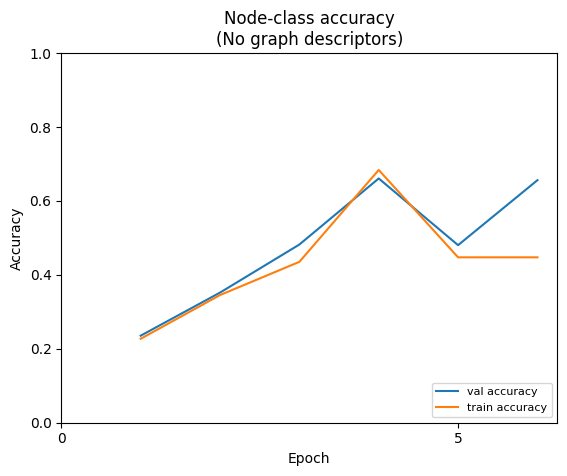

In [ ]:

# Create a list of epoch numbers
epochs = list(range(1, len(accuracy_values[0]) + 1))



# Plot the accuracy values against the epoch numbers
plt.plot(epochs, accuracy_values[0], label=f'val accuracy')
plt.plot(epochs, accuracy_values[8], label=f'train accuracy')
#plt.plot(epochs, accuracy_values[5], label=f'Pub: POI, Linker, E3')
#plt.plot(epochs, accuracy_values[1], label=f'Pub:      Linker, E3  NoPub: POI')
#plt.plot(epochs, accuracy_values[3], label=f'Pub: POI,         E3  NoPub: Linker')
#plt.plot(epochs, accuracy_values[2], label=f'Pub: POI, Linker,     NoPub: E3')
#plt.plot(epochs, accuracy_values[6], label=f'Pub:              E3  NoPub: POI, Linker')
#plt.plot(epochs, accuracy_values[7], label=f'Pub: POI              NoPub: Linker, E3')
#plt.plot(epochs, accuracy_values[4], label=f'Pub:                  NoPub: POI, Linker, E3')



# Add labels and title to the plot
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Node-class accuracy\n(No graph descriptors)')

# Set the x-axis to only show whole numbers
plt.xticks(range(0, len(epochs)+1,5))

# Set the y-axis limits to span from 0 to 1
plt.ylim(0, 1)

# Move the legend to the bottom right corner
plt.legend(loc='lower right', bbox_to_anchor=(1.0, 0.0), prop={'size': 8})

# Display the plot
print("AZ Anon Murcko Scaffold substructure match Public")
print(test_set_names_core)
plt.show()



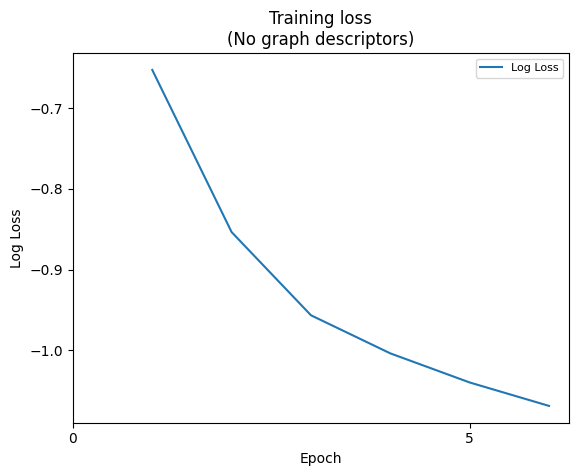

In [ ]:
# Create a list of epoch numbers
epochs = list(range(1, len(accuracy_values[0]) + 1))

from math import log

log_loss_list = [log(loss,10) for loss in loss_list]

# Plot the accuracy values against the epoch numbers
plt.plot(epochs, log_loss_list, label=f'Log Loss')




# Add labels and title to the plot
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('Training loss\n(No graph descriptors)')

# Set the x-axis to only show whole numbers
plt.xticks(range(0, len(epochs)+1,5))

# Set the y-axis limits to span from 0 to 1
#plt.ylim(0, 1)

# Move the legend to the bottom right corner
plt.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0), prop={'size': 8})

# Display the plot
plt.show()

In [ ]:
""" No graph descriptors, without recursive predictions of labels
Epoch 1: Loss: 0.6609857269242162, Val Accuracy: 0.7684370918589465
Epoch 2: Loss: 0.47540812419289774, Val Accuracy: 0.8353069220722682
Epoch 3: Loss: 0.40508898413266803, Val Accuracy: 0.8539399216369177
Epoch 4: Loss: 0.36945939222554286, Val Accuracy: 0.8606007836308228
Epoch 5: Loss: 0.3453694614683548, Val Accuracy: 0.8736177622986504
Epoch 6: Loss: 0.3286879391923465, Val Accuracy: 0.8776229865041358
Epoch 7: Loss: 0.31486161196187057, Val Accuracy: 0.878014801915542
Epoch 8: Loss: 0.30634961472926, Val Accuracy: 0.8925990422289943
Epoch 9: Loss: 0.2917316204033629, Val Accuracy: 0.8564214192424902
Epoch 10: Loss: 0.28528244770895383, Val Accuracy: 0.8981279930343927
Epoch 11: Loss: 0.2766986971777034, Val Accuracy: 0.9029603831084022
Epoch 12: Loss: 0.27348323582157574, Val Accuracy: 0.8921636917718764
Epoch 13: Loss: 0.26387562495121947, Val Accuracy: 0.891162385720505
Epoch 14: Loss: 0.26085822126838315, Val Accuracy: 0.8983021332172398
Epoch 15: Loss: 0.25499014398515674, Val Accuracy: 0.8969525468001741

 No graph descriptors, more RDKit descriptors
Epoch 1: Loss: 0.5915545519247977, Val Accuracy: 0.8105790161079669
Epoch 2: Loss: 0.38348508839459855, Val Accuracy: 0.8838484980409229
Epoch 3: Loss: 0.322334529936334, Val Accuracy: 0.8979973878972572
Epoch 4: Loss: 0.2912615137683645, Val Accuracy: 0.9027427078798432
Epoch 5: Loss: 0.27202009187522724, Val Accuracy: 0.895690030474532
Epoch 6: Loss: 0.2547126731535043, Val Accuracy: 0.91162385720505
Epoch 7: Loss: 0.24650338613886202, Val Accuracy: 0.9126686983021333
Epoch 8: Loss: 0.23542749444709815, Val Accuracy: 0.8952982150631258
Epoch 9: Loss: 0.22525550769082184, Val Accuracy: 0.9118415324336091
Epoch 10: Loss: 0.2172198552368565, Val Accuracy: 0.9200261210274271
Epoch 11: Loss: 0.21033756338349988, Val Accuracy: 0.9272094035698738
Epoch 12: Loss: 0.20665528589498272, Val Accuracy: 0.928036569438398
Epoch 13: Loss: 0.19682833343194645, Val Accuracy: 0.9304745319982586
Epoch 14: Loss: 0.19294776737084357, Val Accuracy: 0.9302133217239879
Epoch 15: Loss: 0.1894932356739386, Val Accuracy: 0.9198955158902917


No graph descriptors, WITH recursive predictions of labels               (Built into GNN. Tried also applying same structure to training function, but gave acc around 65)
Epoch 1: Loss: 0.6684036113199641, Val Accuracy: 0.8009577710056596
Epoch 2: Loss: 0.4794131662096075, Val Accuracy: 0.8549847627340009
Epoch 3: Loss: 0.40269028649619615, Val Accuracy: 0.8350021767522856
Epoch 4: Loss: 0.3656960101721839, Val Accuracy: 0.864867218110579
Epoch 5: Loss: 0.34412561228519173, Val Accuracy: 0.8925119721375707
Epoch 6: Loss: 0.31920113086018487, Val Accuracy: 0.8900304745319982
Epoch 7: Loss: 0.30664670950468487, Val Accuracy: 0.8470613844144537
Epoch 8: Loss: 0.3023727468960496, Val Accuracy: 0.885111014366565
Epoch 9: Loss: 0.2862570651214, Val Accuracy: 0.8347845015237266
Epoch 10: Loss: 0.2804886923525279, Val Accuracy: 0.908619939050936
Epoch 11: Loss: 0.27115953319370134, Val Accuracy: 0.9019590770570309
Epoch 12: Loss: 0.27247652720247745, Val Accuracy: 0.8914235959947758
Epoch 13: Loss: 0.256741512196566, Val Accuracy: 0.906878537222464
Epoch 14: Loss: 0.25835099650669047, Val Accuracy: 0.899782324771441
Epoch 15: Loss: 0.2486661559179466, Val Accuracy: 0.9061384414453635
def forward(self, node_attr, edge_index): #, edge_attr):
        # First Graph Convolution Layer
        z = self.conv1(node_attr, edge_index)#, edge_attr)
        z = F.relu(z)

        # Second Graph Convolution Layer
        z = self.conv2(z, edge_index)#, edge_attr)
        z = F.relu(z)

        # Third Graph Convolution Layer
        z = self.conv3(z, edge_index)#, edge_attr)
        z = F.relu(z)

        # Output Layer
        y_initial = self.out(z)

        #Second round
        pred_inital = y_initial.argmax(dim=1)
        node_attr_new = node_attr
        node_attr_new[:,0] = pred_inital 

        z = self.conv1(node_attr_new, edge_index)#, edge_attr)
        z = F.relu(z)

        # Second Graph Convolution Layer
        z = self.conv2(z, edge_index)#, edge_attr)
        z = F.relu(z)

        # Third Graph Convolution Layer
        z = self.conv3(z, edge_index)#, edge_attr)
        z = F.relu(z)

        y = self.out(z)

        return y

With graph descriptors and more RDKit descriptors
Epoch 1: Loss: 0.49145384940008324, Val Accuracy: 0.8717892903787549
Epoch 2: Loss: 0.31605881135885305, Val Accuracy: 0.8966478014801915
Epoch 3: Loss: 0.27385839570283155, Val Accuracy: 0.9070091423595995
Epoch 4: Loss: 0.2501240358026342, Val Accuracy: 0.9125380931649978
Epoch 5: Loss: 0.22939350262864447, Val Accuracy: 0.9142794949934697
Epoch 6: Loss: 0.21382954726988052, Val Accuracy: 0.9201567261645625
Epoch 7: Loss: 0.2062745038407239, Val Accuracy: 0.9250761863299957
Epoch 8: Loss: 0.19714977896945357, Val Accuracy: 0.9247714410100131
Epoch 9: Loss: 0.18867836165740637, Val Accuracy: 0.9285154549412277
Epoch 10: Loss: 0.1819830511345482, Val Accuracy: 0.9319982585981715
Epoch 11: Loss: 0.17483279560094628, Val Accuracy: 0.9319547235524598
Epoch 12: Loss: 0.16987394453331706, Val Accuracy: 0.9352198519808446
Epoch 13: Loss: 0.16219402956165618, Val Accuracy: 0.9325642141924249
Epoch 14: Loss: 0.16130290660928284, Val Accuracy: 0.9371789290378755
Epoch 15: Loss: 0.15739321986040294, Val Accuracy: 0.9435785807575098
"""

In [ ]:
if save_model is True:
    if model_name is False:
        model_name = f'model_{dataname}_FullAibeDataset.pth'
    torch.save(model, model_name)


In [ ]:
#Manual loading of a model
#model = torch.load('GraphConv_3_BoundaryNodeSplitter_3layers_{dataname}')
#model.eval()

# Plotting & Evaluation

## Plotting functions

In [ ]:

def vizualize_graph_descriptor(smile=None, print_line_graph=False, chosen_function=None, chosen_descriptor=None):        #Functional, not pretty. Work in progress
    """mol = Chem.MolFromSmiles(smile)
    AllChem.Compute2DCoords(mol)
    Graph = nx.Graph()
    for atom in mol.GetAtoms():
        Graph.add_node(atom.GetIdx(),
                   atomic_num=atom.GetAtomicNum(),)
    for bond in mol.GetBonds():
        Graph.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(),
                   bond_type=bond.GetBondType())

    # Assign 2D coordinates to nodes
    conf = mol.GetConformer()
    for atom in mol.GetAtoms():
        pos = conf.GetAtomPosition(atom.GetIdx())
        Graph.nodes[atom.GetIdx()]['pos'] = (pos.x, pos.y)
    pos = nx.get_node_attributes(Graph, 'pos')"""

    Graph, pos = make_graph_with_pos(smile)

    if print_line_graph is True:
        #Graph_L = nx.line_graph(Graph)
        Graph_L = line_graph_custom(Graph)
        #edge_centroids = compute_edge_centroids(Graph, pos)
        edge_centroids = {}
        for edge in Graph.edges():
            p1 = pos[edge[0]]
            p2 = pos[edge[1]]
            centroid = ((p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2)
            edge_centroids[edge] = centroid
        pos_Graph_L = {node: edge_centroids[Graph_L.nodes[node]['edge']] for node in Graph_L.nodes()}
        Graph = Graph_L
        pos = pos_Graph_L

    if chosen_descriptor is None:
        if chosen_function is not None:
            chosen_descriptor = chosen_function(Graph)
        else:
            raise ValueError('Input either chosen_descriptor or chosen_function!')

    #Calculator node colors
    if isinstance(chosen_descriptor, dict):
        chosen_descriptor_list=[]
        for key, value in chosen_descriptor.items():
            chosen_descriptor_list.append(value) 
        chosen_descriptor = np.array(chosen_descriptor_list)
    norm_values = normalize(chosen_descriptor) 
    colors = [(0, 0, 0, 1), (1, 0, 0, 1)]  # RGBA tuples
    colormap = LinearSegmentedColormap.from_list('black_to_red', colors, N=100)
    colours = [colormap(x) for x in norm_values]
    
    plt.figure(figsize=(6, 4))
    nx.draw(Graph, pos, node_color=colours, with_labels=False, node_size=100)
    plt.axis('equal')

def vizualize_protac_From_Graph(graph, node_size=100, highlighted_nodes=[]):  # By atom color
    atom_color_mapping = {
        6: 'gray',   # Carbon
        7: 'blue',   # Nitrogen
        8: 'red',    # Oxygen
        16: 'yellow', # Sulfur
        53: 'purple', # Iodine
        9: 'pink',   # Fluoride (Fluorine)
        17: 'green',  # Chloride (Chlorine)
        35: 'orange',  # Bromine
    }
    highlight_color = 'gold'  # Color for highlighted nodes
    #colors = [atom_color_mapping[[d for n, d in graph.nodes.items()][node]['atomic_num']] for node in range(len(graph))]
    colors = [highlight_color if node in highlighted_nodes else atom_color_mapping[[d for n, d in graph.nodes.items()][node]['atomic_num']] for node in range(len(graph))]


    try: 
        plt.figure(figsize=(6, 4))
        pos = nx.get_node_attributes(graph, 'pos')
        nx.draw(graph, pos=pos, node_color=colors, with_labels=False, node_size=node_size)       #NO POS!!!!
    except:
        plt.close()
        plt.figure(figsize=(6, 4))
        nx.draw(graph, node_color=colors, with_labels=False, node_size=node_size)       #NO POS!!!!

    # Plotting
    
    plt.axis('equal')
    plt.show()

def make_groundtruth_graph(protac_smile, substructure_smiles):#(protac_mol, substructure_mapping):                                               ###########  WIP
    #protac_mol = Chem.MolFromSmiles(protac_smile)
    #protac_smile, poi_smile, e3_smile = substructure_split_sort(substructure_smiles)
    #substructure_mapping = create_protac_substructure_mapping(protac_smile, poi_smile, e3_smile)
    protac_mol = Chem.MolFromSmiles(protac_smile)
    AllChem.Compute2DCoords(protac_mol)
    poi_smile, linker_smile, e3_smile = substructure_split_sort(substructure_smiles)
    substructure_mapping = create_protac_substructure_mapping(protac_smile, poi_smile, e3_smile)

    G = nx.Graph()

    # Add nodes with coordinates and color coding
    for atom in protac_mol.GetAtoms():
        atom_idx = atom.GetIdx()
        pos = protac_mol.GetConformer().GetAtomPosition(atom_idx)
        #color = determine_color(substructure_mapping, atom_idx)
        if atom_idx in substructure_mapping['E3']:
            color = 'blue'
        elif atom_idx in substructure_mapping['Linker']:
            color = 'gray'
        elif atom_idx in substructure_mapping['POI']:
            color = 'red'
        else:
            color = 'black'  # Default color
        G.add_node(atom_idx, pos=(pos.x, pos.y), color=color)

    # Add edges
    for bond in protac_mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())

    colors = [G.nodes[node]['color'] for node in G.nodes]

    return G, colors


                                                       ###########  WIP
def vizualize_protac_From_Smile(smile, node_size=100):  # By atom color
    atom_color_mapping = {
    'C': 'gray',     # Carbon
    'N': 'blue',     # Nitrogen
    'O': 'red',      # Oxygen
    'S': 'yellow',   # Sulfur
    'I': 'purple',   # Iodine
    'F': 'teal',    # Fluoride
    'Cl': 'green',    # Chloride
    }
    # Convert SMILES to RDKit Molecule
    mol = Chem.MolFromSmiles(smile)

    # Create a networkx graph from the RDKit molecule
    graph = nx.Graph()
    for atom in mol.GetAtoms():
        graph.add_node(atom.GetIdx(), color=atom.GetSymbol())  # Store atom symbol

    for bond in mol.GetBonds():
        graph.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())

    # Assign positions to the graph
    graph, pos = assign_pos_to_graph(smile, graph)

    # Map atom symbols to colors
    colors = [atom_color_mapping.get(graph.nodes[node]['color'], 'black') for node in graph.nodes]

    # Plotting
    plt.figure(figsize=(6, 4))
    nx.draw(graph, pos, node_color=colors, with_labels=False, node_size=node_size)
    plt.axis('equal')
    plt.show()




def vizualize_predicted_nodes(G):                                                ###########  WIP
    return []




def draw_smiles_with_titles(protac_smile, substructure_smiles):
    """
    Draws molecule structures for the given SMILES strings with titles.

    Args:
    protac_smile (str): SMILES string for the PROTAC molecule.
    poi_smile (str): SMILES string for the POI molecule.
    linker_smile (str): SMILES string for the Linker molecule.
    e3_smile (str): SMILES string for the E3 molecule.

    Returns:
    A matplotlib figure containing the rendered molecule structures with titles.
    """
    # Convert SMILES to RDKit Mol objects
    poi_smile, linker_smile, e3_smile = substructure_split_sort(substructure_smiles)
    smiles_list = [protac_smile, poi_smile, linker_smile, e3_smile]
    titles = ["PROTAC", "POI", "Linker", "E3"]
    mols = [Chem.MolFromSmiles(smile) for smile in smiles_list]

    # Create a subplot grid
    num_mols = len(mols)
    fig, axs = plt.subplots(1, num_mols, figsize=(15, 5))

    # Render each molecule in its respective subplot
    for i, (mol, title) in enumerate(zip(mols, titles)):
        if mol:  # Check if the molecule is valid
            img = Draw.MolToImage(mol)
            axs[i].imshow(img)
            axs[i].axis('off')
            axs[i].set_title(title)
        else:
            axs[i].set_visible(False)

    plt.tight_layout()
    #return fig


def convert_fig_to_image(fig):
    """ Convert a Matplotlib figure to a PIL Image. """
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
    buf.seek(0)
    img = Image.open(buf)
    return img

def combine_two_figures(fig1, fig2):
    # Convert figures to images
    img1 = convert_fig_to_image(fig1)
    img2 = convert_fig_to_image(fig2)

    # Create a new figure for combining the images
    fig, axs = plt.subplots(1, 2, figsize=(12*1.3, 6*1.3))

    # Display images
    axs[0].imshow(np.asarray(img1))
    axs[0].axis('off')  # Turn off axis
    axs[1].imshow(np.asarray(img2))
    axs[1].axis('off')  # Turn off axis

    plt.show()


def highlight_multiple_substructures_and_graph(mol_smiles, substructure_smiles, print_smiles=False):
    """
    Draws a molecule with highlighted bonds where the substructures attach to the rest of the molecule.
    Additionally, it outputs a NetworkX graph and the indices of the corresponding bonds.
    
    Parameters:
    mol_smiles (str): The SMILES string of the molecule.
    substruct_smiles_list (list): A list of SMILES strings of the substructures with dummy atoms.
    
    Returns:
    G (NetworkX graph): The graph representation of the molecule.
    edge_indices (list): The indices of the atoms forming the corresponding bonds in the graph.
    """
    mol = Chem.MolFromSmiles(mol_smiles)
    G = nx.Graph()
    edge_indices = []
    circles_svg = ""

    # Add edges from the molecule to the graph
    for bond in mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())

    # Create a drawer with an SVG renderer
    drawer = rdMolDraw2D.MolDraw2DSVG(400, 400)
    drawer.DrawMolecule(mol)

    poi_smile, linker_smile, e3_smile = substructure_split_sort(substructure_smiles)
    # Process each substructure
    for substruct_smiles in [poi_smile, e3_smile]:
        substruct_mol = Chem.MolFromSmiles(substruct_smiles)
        matches = mol.GetSubstructMatches(Chem.DeleteSubstructs(substruct_mol, Chem.MolFromSmiles('*')))

        if not matches:
            continue  # If no match is found, skip to the next substructure

        match = matches[0]  # Take the first match                                                                    #OBS! WIP! I need a function that can return "the" match which is correct

        # Find the corresponding bond
        for bond in mol.GetBonds():
            begin_atom_label = int(bond.GetBeginAtomIdx() in match)
            end_atom_label = int(bond.GetEndAtomIdx() in match)
            if begin_atom_label != end_atom_label:
                edge_indices.append((bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()))

                # Calculate the midpoint of the bond for the SVG circle
                draw_coords = (drawer.GetDrawCoords(bond.GetBeginAtomIdx()),
                               drawer.GetDrawCoords(bond.GetEndAtomIdx()))
                mid_x = (draw_coords[0].x + draw_coords[1].x) / 2
                mid_y = (draw_coords[0].y + draw_coords[1].y) / 2
                radius = 4
                circles_svg += f'<circle cx="{mid_x}" cy="{mid_y}" r="{radius}" stroke="red" stroke-width="1" fill="none"/>'

    #Create an unique set of edges
    sorted_edge_indices = [tuple(sorted(t)) for t in edge_indices]

    # Step 2: Convert the list of sorted tuples to a set to remove duplicates
    unique_edge_set = set(sorted_edge_indices)

    # Step 3: Convert the set back to a list
    unique_edge_indices = list(unique_edge_set)


    if not edge_indices:
        print("No corresponding bonds were found.")
        return G, None

    # Finish the drawing and get the SVG text
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText().replace('svg:', '')

    # Add the circles to the SVG
    svg_with_circles = re.sub('</svg>', circles_svg + '</svg>', svg)

    # Display the modified SVG
    display(SVG(svg_with_circles))

    if print_smiles is True:
        print(f'PROTAC: {mol_smiles}')
        print(f'POI: {poi_smile}')
        print(f'Linker: {linker_smile}')
        print(f'E3: {e3_smile}')
    return G, unique_edge_indices


['blue', 'red', 'blue', 'blue', 'blue', 'red', 'red', 'blue', 'blue', 'red', 'red', 'red', 'red', 'blue', 'red', 'blue', 'red', 'blue', 'blue', 'red', 'red', 'blue', 'red', 'red', 'red', 'blue', 'red', 'red', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'blue', 'red', 'red', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'blue', 'red', 'blue', 'red', 'blue', 'blue', 'red', 'red', 'blue', 'red', 'red', 'red', 'blue', 'red', 'red', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'blue']


(-28.37187389618922, 28.37187389618922, -9.520474944967306, 9.520474944967305)

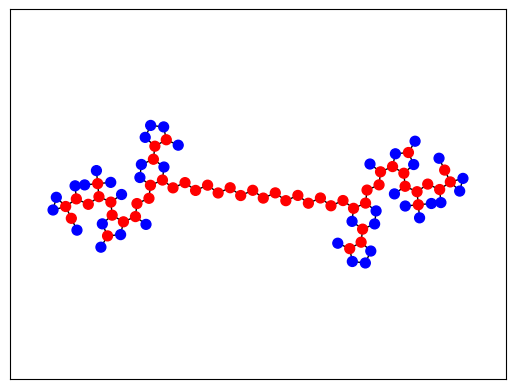

In [ ]:
smi = 'Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(C#N)CC2)C(C)(C)C)c(OCCOCCOCCOCCOCCOc2cc(-c3scnc3C)ccc2CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(C#N)CC2)C(C)(C)C)c1'
G, pos = make_graph_with_pos(smi)

bool_list, highlighted_nodes = identify_bridge_nodes(G)

colors = []
for node_idx in range(G.number_of_nodes()):
    if node_idx in highlighted_nodes:
        colors.append('red')
    else:
        colors.append('blue')

#colors = ['red' if node_idx in highlighted_nodes else 'blue' for node_idx in range(G.number_of_nodes())]
print(colors)
nx.draw_networkx(G, pos=pos,  node_color=colors, with_labels=False, node_size = 50)
plt.axis('equal')

(-28.37187389618922, 28.37187389618922, -9.520474944967306, 9.520474944967305)

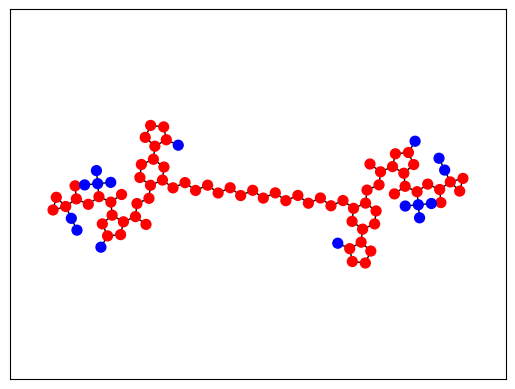

In [ ]:
from rdkit.Chem.Scaffolds import MurckoScaffold
smi = 'Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(C#N)CC2)C(C)(C)C)c(OCCOCCOCCOCCOCCOc2cc(-c3scnc3C)ccc2CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(C#N)CC2)C(C)(C)C)c1'
mol = Chem.MolFromSmiles(smi)


ms_bool_list, at_idx_list = identify_murcko_scaffold_atoms(mol)

G, pos = make_graph_with_pos(smi)

colors = []
for node_idx in range(G.number_of_nodes()):
    if node_idx in at_idx_list:
        colors.append('red')
    else:
        colors.append('blue')

nx.draw_networkx(G, pos=pos,  node_color=colors, with_labels=False, node_size = 50)
plt.axis('equal')


['blue', 'red', 'blue', 'blue', 'blue', 'red', 'red', 'blue', 'blue', 'red', 'red', 'red', 'red', 'blue', 'red', 'blue', 'red', 'blue', 'blue', 'red', 'red', 'blue', 'red', 'red', 'red', 'blue', 'red', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'blue', 'red', 'red', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'blue', 'red', 'blue', 'red', 'blue', 'blue', 'red', 'red', 'blue', 'red', 'red', 'red', 'blue', 'red', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue']


(-28.37187389618922, 28.37187389618922, -9.520474944967306, 9.520474944967305)

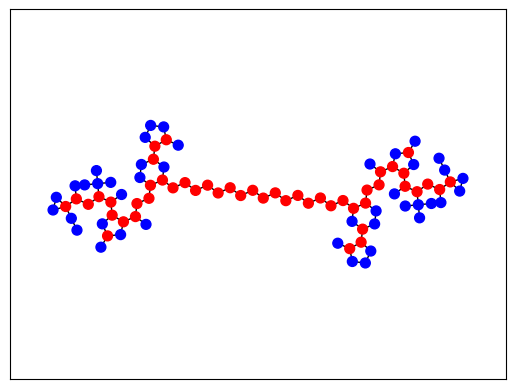

In [ ]:
smi = 'Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(C#N)CC2)C(C)(C)C)c(OCCOCCOCCOCCOCCOc2cc(-c3scnc3C)ccc2CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(C#N)CC2)C(C)(C)C)c1'
G, pos = make_graph_with_pos(smi)

bridge_bool_list, highlighted_nodes = identify_bridge_nodes(G)
ms_bool_list, at_idx_list = identify_murcko_scaffold_atoms(mol)


colors = []
for b1, b2 in zip(bridge_bool_list, ms_bool_list):
    if b1*b2:
        colors.append('red')
    else:
        colors.append('blue')

#colors = ['red' if node_idx in highlighted_nodes else 'blue' for node_idx in range(G.number_of_nodes())]
print(colors)
nx.draw_networkx(G, pos=pos,  node_color=colors, with_labels=False, node_size = 50)
plt.axis('equal')


[1, 5, 6, 9, 10, 11, 12, 14, 16, 19, 20, 22, 23, 24, 26, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 54, 55, 59, 63, 64, 65, 66, 68, 70, 73, 74, 76, 77, 78, 80]


(-28.37187389618922, 28.37187389618922, -9.520474944967306, 9.520474944967305)

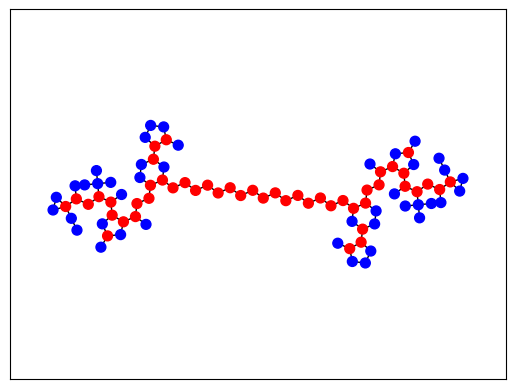

In [ ]:
smi = 'Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(C#N)CC2)C(C)(C)C)c(OCCOCCOCCOCCOCCOc2cc(-c3scnc3C)ccc2CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(C#N)CC2)C(C)(C)C)c1'
mol = Chem.MolFromSmiles(smi)
#G, pos = make_graph_with_pos(smi)

#bridge_bool_list, highlighted_nodes = identify_bridge_nodes_and_reject_small_splits(G, smallest_allowed_subgraph_size=9)
#ms_bool_list, at_idx_list = identify_murcko_scaffold_atoms(mol)

bool_combined_list, at_idx_combined_list = identify_legal_nodes(mol, smallest_allowed_subgraph_size=10)


colors = []
for b in bool_combined_list:
    if b:
        colors.append('red')
    else:
        colors.append('blue')

print(at_idx_combined_list)

nx.draw_networkx(G, pos=pos,  node_color=colors, with_labels=False, node_size = 50)
plt.axis('equal')

## Evaluation functions

In [ ]:
def MaxCommonSubstructure_maxatoms(true_class_labels, predicted_class_labels): #input: list, torch tensor?
    MCS_maxatoms_substructures = [-1, -1, -1] #initialize variable
    for label in [0, 1, 2]: #[POI, Linker, E3]
        indicies_substructure = [ true_label == label for true_label in true_class_labels]
        indicies_substructure_pred = [ pred_label == label for pred_label in predicted_class_labels]
        indicies_pred_is_substructure = [ bool_substructure and bool_substructure_pred for bool_substructure, bool_substructure_pred in zip(indicies_substructure,indicies_substructure_pred)]

        num_atoms_substructure = sum(indicies_substructure)
        num_atoms_substructure_pred = sum(indicies_substructure_pred)
        num_atoms_intersection_pred_true = sum(indicies_pred_is_substructure)
        union_num_atoms_pred_true = num_atoms_substructure + num_atoms_substructure_pred - num_atoms_intersection_pred_true
        num_atoms_maximum_common_substructure_pred_true = num_atoms_intersection_pred_true

        MCS_maxatoms_substructures[label] = num_atoms_maximum_common_substructure_pred_true / union_num_atoms_pred_true

    return MCS_maxatoms_substructures

def mislabelled_nodes_in_substructures(true_class_labels, predicted_class_labels):
    mislabelled_nodes_list = [0, 0, 0] #initialize variable
    for label in [0, 1, 2]: #[POI, Linker, E3]
        indicies_substructure = [ true_label == label for true_label in true_class_labels] # returns bool of which atoms are truely the substructure
        indicies_substructure_pred = [ pred_label == label for pred_label in predicted_class_labels] # returns bool of predicted substructure 
        indicies_correct_prediction = [ bool_substructure and bool_substructure_pred for bool_substructure, bool_substructure_pred in zip(indicies_substructure,indicies_substructure_pred)] #Correct prediction

        num_atoms_substructure = sum(indicies_substructure)
        num_atoms_correct_prediction = sum(indicies_correct_prediction)
        num_atoms_incorrect_prediction = num_atoms_substructure - num_atoms_correct_prediction

        mislabelled_nodes_list[label] = num_atoms_incorrect_prediction

    return mislabelled_nodes_list

def generate_3x3confusion_matrix(true_class_labels, class_predictions):
    # Confusion matrix initialization (3x3 matrix filled with 0s)
    confusion_matrix = [[0, 0, 0] for _ in range(3)]

    # Populating the confusion matrix
    for true_label, predicted_label in zip(true_class_labels, class_predictions):
        confusion_matrix[true_label][predicted_label] += 1

    return confusion_matrix

def add_3x3confusion_matrices(matrix1, matrix2):
    # Assuming both matrices are of the same size
    num_rows = len(matrix1)
    num_cols = len(matrix1[0])
    
    # Initialize a new matrix with the same size
    result_matrix = [[0 for _ in range(num_cols)] for _ in range(num_rows)]

    # Add the corresponding elements of matrix1 and matrix2
    for i in range(num_rows):
        for j in range(num_cols):
            result_matrix[i][j] = matrix1[i][j] + matrix2[i][j]

    return result_matrix

def check_permutation_invariance(molecule_data, model, class_predictions, probabilities):
    num_nodes = molecule_data.num_nodes
    shuffle_indicies_dictionary = {} 
    int_list = list(range(0, num_nodes))
    np.random.shuffle(int_list)
    x_shuffeled = molecule_data.x.clone()
    
    G_pred = molecule_data.G.copy()

    for i in range(num_nodes):
        shuffle_indicies_dictionary[i] = int_list[i]   #dict[old] = shuffled
    for i in range(num_nodes):
        shuffled_index = shuffle_indicies_dictionary[i]
        x_shuffeled[shuffled_index] = molecule_data.x[i] 
        shuffled_edge_index = molecule_data.edge_index.clone()
    for i in range(len(molecule_data.edge_index[0])):
        start_node = molecule_data.edge_index[0][i].item()
        end_node = molecule_data.edge_index[1][i].item()
        shuffled_edge_index[0][i] = shuffle_indicies_dictionary[start_node]
        shuffled_edge_index[1][i] = shuffle_indicies_dictionary[end_node]


    molecule_data_shuffeled = Data(x=x_shuffeled, edge_index=shuffled_edge_index, G=G_pred, dictionary_shuffeled_indicies=shuffle_indicies_dictionary)
    class_predictions_shuffeled, probabilities_shuffeled = predict(model, molecule_data_shuffeled) 

    text = "Permutation invariant"
    for i in range(num_nodes):
        if class_predictions[i] == class_predictions_shuffeled[shuffle_indicies_dictionary[i]] is False:
            text = "Not permutation invariant!"
            raise IndexError("Not permutation invariant!")
        #If I can shuffle the nodes and edges, run the prediction, then unshuffle the nodes and edges, and still have the same result as if I didn't shuffle -> Then shuffeling does not affect result => Permutation invariant
    return text


def unpack_datapoint(chosen_dataset, idx):
    chosen_datapoint=chosen_dataset[idx]
    protac_smile = chosen_datapoint.smiles
    substructure_smiles = chosen_datapoint.substructure_smiles
    poi_smile, linker_smile, e3_smile = substructure_split_sort(substructure_smiles)
    #protac_mol = Chem.MolFromSmiles(protac_smile)
    G_pred=chosen_datapoint.G

    # Create a data object
    molecule_data = Data(x=chosen_datapoint.x, edge_index=chosen_datapoint.edge_index, G=G_pred)
    return molecule_data, G_pred, protac_smile, substructure_smiles, poi_smile, linker_smile, e3_smile

## Plots & metrics

In [ ]:
scale_factor_nodes=1.8 
chosen_dataset = test_dataset_5 #val_dataset
#mode = modes[0]
if mode == modes[0]:
    prediction_range = range(num_plotted_protacs)        
else: 
    prediction_range = range(len(chosen_dataset))


NameError: name 'mode' is not defined

In [ ]:
num_mislabelled = {}
num_mislabelled_POI = {}
num_mislabelled_Linker = {}
num_mislabelled_E3 = {}
POI_MCS_maxatoms_list = []
Linker_MCS_maxatoms_list = []
E3_MCS_maxatoms_list = []
Confusion3Matrix_sum = [[0, 0, 0], [0, 0, 0], [0, 0, 0]]


challenging_idx = [244] #[78, 85, 114, 115, 130, 244, 308]

for idx in prediction_range:# prediction_range:
    #Prediction
    molecule_data, G_pred, protac_smile, substructure_smiles, poi_smile, linker_smile, e3_smile = unpack_datapoint(chosen_dataset, idx)
    class_predictions, probabilities = predict(model, molecule_data)

    

    #check
    POI_boundary_node, E3_boundary_node= get_predicted_boundary_nodes(model, molecule_data)
    
    model.eval()
    with torch.no_grad():
        out = model(molecule_data.x, molecule_data.edge_index)
    intermediate_path_nodes, path_nodes, POI_nodes, linker_nodes,  E3_nodes = process_boundaries_to_substructures(molecule_data, out, return_intermediate_path_nodes=True)
    #vizualize_protac_From_Graph(G_pred, node_size=80)
    #vizualize_protac_From_Graph(G_pred, node_size=80, highlighted_nodes=[POI_boundary_node])
    #print(f'intermediate_path_nodes.tolist(): {intermediate_path_nodes}')
    #vizualize_protac_From_Graph(G_pred, node_size=80, highlighted_nodes=path_nodes)
    check_permutation_invariance(molecule_data, model, class_predictions, probabilities) #Raises an error if not permutation invariant
    
    #printing
    class_predictions_list = class_predictions.tolist()
    color_mapping = {0: 'red', 1: 'gray', 2: 'blue'}     # Define color mapping
    colours_pred = [color_mapping[class_pred] for class_pred in class_predictions_list]     # Map each class prediction to its corresponding color

    # Create a figure and axes for the predicted graph
    G_pred, pos = assign_pos_to_graph(smile=protac_smile, G=G_pred)
    fig_pred, ax_pred = plt.subplots(figsize=(6*scale_factor_nodes, 4*scale_factor_nodes))
    nx.draw(G_pred, pos, node_color=colours_pred, with_labels=False, node_size=100, ax=ax_pred)
    ax_pred.set_title("Predicted")
    ax_pred.axis('equal')
    ax_pred.axis('off')  # Optional: to turn off the axis
    plt.close(fig_pred)  # Close the figure to prevent it from being displayed

    # Create a figure and axes for the ground truth graph
    G_gt, colors_groundtruth = make_groundtruth_graph(protac_smile, substructure_smiles)
    
    fig_gt, ax_gt = plt.subplots(figsize=(6*scale_factor_nodes, 4*scale_factor_nodes))
    nx.draw(G_gt, pos, node_color=colors_groundtruth, with_labels=False, node_size=100, ax=ax_gt)
    ax_gt.set_title("Ground Truth")
    ax_gt.axis('equal')
    ax_gt.axis('off')  # Optional: to turn off the axis
    plt.close(fig_gt)  # Close the figure to prevent it from being displayed

    if mode == modes[0]:
        print('index: ', idx)
        print('protac_smile', protac_smile)
        # Combine and display the two figures
        combine_two_figures(fig_gt, fig_pred)

    

    # ------------------- Calculations for evaluation metrics below -------------------

    
    substruct_smiles=chosen_dataset[idx].substructure_smiles
    poi_smile, linker_smile, e3_smile = substructure_split_sort(substruct_smiles)
    one_hot_direct = one_hot_encode_substructure_labels(protac_smile, poi_smile, e3_smile)
    node_feature_dim = training_dataset.num_node_features 
    edge_feature_dim = training_dataset.num_edge_features



    # Num nodes mislabelled nodes for whole PROTAC. For bar plot
    total_num_nodes = len(chosen_dataset[idx].node_substructure_label.argmax(dim=1))
    correctly_labled_nodes = class_predictions.eq(chosen_dataset[idx].node_substructure_label.argmax(dim=1)).sum().item()
    num_mislabelled_nodes = total_num_nodes - correctly_labled_nodes
    if num_mislabelled_nodes in num_mislabelled:
        num_mislabelled[num_mislabelled_nodes] += 1
    else:
        num_mislabelled[num_mislabelled_nodes] = 1

    
    # Get maximum common substructure (correctly labeled nodes / (union of predicted nodes and true nodes))
    true_class_labels = chosen_dataset[idx].node_substructure_label.argmax(dim=1)
    #print(f'true_class_labels: {true_class_labels}')
    #print(f'class_predictions: {class_predictions}')
    MCS_maxatoms_substructures = MaxCommonSubstructure_maxatoms(true_class_labels, class_predictions)
    for class_label in [0, 1, 2]:
        if class_label == 0:
            POI_MCS_maxatoms_list.append(MCS_maxatoms_substructures[0].numpy())
        elif class_label == 1:
            Linker_MCS_maxatoms_list.append(MCS_maxatoms_substructures[1].numpy())
        elif class_label == 2:
            E3_MCS_maxatoms_list.append(MCS_maxatoms_substructures[2].numpy())
        else:
            raise ValueError(f'MaxCommonSubstructure_maxatoms() gives a bad output')


    #Get num mislabeled for individual substructures
    incorrect_predicted_labels_substructure_list = mislabelled_nodes_in_substructures(true_class_labels, class_predictions)
    num_mislabelled_list = [num_mislabelled_POI, num_mislabelled_Linker, num_mislabelled_E3]
    num_mislabelled_nodes_list = [0, 0, 0]
    for class_label in [0, 1, 2]:
        num_mislabelled_nodes_substructure = incorrect_predicted_labels_substructure_list[class_label].item()     
        num_mislabelled_nodes_list[class_label] += num_mislabelled_nodes_substructure
        if num_mislabelled_nodes_substructure in num_mislabelled_list[class_label]:
            num_mislabelled_list[class_label][num_mislabelled_nodes_substructure] += 1
        else:
            num_mislabelled_list[class_label][num_mislabelled_nodes_substructure] = 1

        #if class_label == 0:
        #    num_mislabelled_nodes_POI = incorrect_predicted_labels_substructure_list[0].item()
        #    if num_mislabelled_nodes_POI in num_mislabelled_POI:
        #        num_mislabelled_POI[num_mislabelled_nodes_POI] += 1
        #    else:
        #        num_mislabelled_POI[num_mislabelled_nodes_POI] = 1
        #elif class_label == 1:
        #    num_mislabelled_nodes_Linker = incorrect_predicted_labels_substructure_list[1].item()
        #    if num_mislabelled_nodes_Linker in num_mislabelled_Linker:
        #        num_mislabelled_Linker[num_mislabelled_nodes_Linker] += 1
        #    else:
        #        num_mislabelled_Linker[num_mislabelled_nodes_Linker] = 1
        #elif class_label == 2:
        #    num_mislabelled_nodes_E3 = incorrect_predicted_labels_substructure_list[2].item()
        #    if num_mislabelled_nodes_E3 in num_mislabelled_E3:
        #        num_mislabelled_E3[num_mislabelled_nodes_E3] += 1
        #    else:
        #        num_mislabelled_E3[num_mislabelled_nodes_E3] = 1
        #else:
        #    raise ValueError(f'MaxCommonSubstructure_maxatoms gives a bad output')
    
    Confusion3Matrix_protac = generate_3x3confusion_matrix(true_class_labels, class_predictions)
    Confusion3Matrix_sum = add_3x3confusion_matrices(Confusion3Matrix_protac, Confusion3Matrix_sum)

        
    if not num_mislabelled_nodes == sum(num_mislabelled_nodes_list):
        print("MISCOUNTING MISLABELED NODES!")
        print('index: ', idx)
        print('protac_smile', protac_smile)
        print(f'Counted mislabelled nodes PROTAC: {num_mislabelled_nodes}')
        print(f'num_mislabelled_nodes_POI: {num_mislabelled_nodes_list[0]}, num_mislabelled_nodes_Linker: {num_mislabelled_nodes_list[1]}, num_mislabelled_nodes_E3: {num_mislabelled_nodes_list[2]}')
        # Combine and display the two figures
        combine_two_figures(fig_gt, fig_pred)
        raise ValueError(f'Number of counted mislabelled nodes in the whole PROTAC does not match the sum of mislabeling with in each true substructure!')

In [ ]:
#Bar plot for Num nodes mislabelled nodes for whole PROTAC.
plt.bar(num_mislabelled.keys(), num_mislabelled.values(), 1)

plt.title(f'PROTACs ({len(chosen_dataset)}) with x nodes mislabelled')
plt.xlabel('Num Mislabelled')
plt.ylabel('Counts')
plt.show()



In [ ]:
print(f'Num PROTACs in set: {len(POI_MCS_maxatoms_list)}')

fig_width = 15  # Adjust the width as needed
fig_height = 5  # Adjust the height as needed to make subplots square

fig_hist_MCS, axes_hist_MCS = plt.subplots(1, 3, figsize=(fig_width, fig_height))

# Use fig_hist_MCS for setting the super title
fig_hist_MCS.suptitle("'MCS'/max_atoms in Each Substructure", fontsize=16)

substructure_str = ['POI', 'Linker', 'E3']
max_y_val = 0  # Variable to store the maximum y-value across all histograms

# Calculate the maximum y-value without plotting
for X_MCS_maxatoms_list in [POI_MCS_maxatoms_list, Linker_MCS_maxatoms_list, E3_MCS_maxatoms_list]:
    binwidth = 1/25
    bin_setting = np.arange(min(X_MCS_maxatoms_list), max(X_MCS_maxatoms_list) + binwidth, binwidth)
    counts, _ = np.histogram(X_MCS_maxatoms_list, bins=bin_setting)
    max_y_val = max(max_y_val, max(counts))*1.1

# Now plot and set the same y-axis limits
for class_label, X_MCS_maxatoms_list in enumerate([POI_MCS_maxatoms_list, Linker_MCS_maxatoms_list, E3_MCS_maxatoms_list]):
    binwidth = 1/25
    bin_setting = np.arange(0, 1 + binwidth, binwidth)

    axes_hist_MCS[class_label].hist(x=X_MCS_maxatoms_list, bins=bin_setting)
    axes_hist_MCS[class_label].set_ylim(0, max_y_val)  # Set the same y-axis limits
    axes_hist_MCS[class_label].set_xlabel('correct/union_atoms')
    axes_hist_MCS[class_label].set_ylabel('Count')
    axes_hist_MCS[class_label].set_title(f'{substructure_str[class_label]}')

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust the top padding to make room for the super title
plt.show()

In [ ]:
fig_width = 15  # Adjust the width as needed
fig_height = 5  # Adjust the height as needed for the bar plots

fig_bar, axes_bar = plt.subplots(1, 3, figsize=(fig_width, fig_height))
fig_bar.suptitle("Structures with x nodes mislabelled", fontsize=16)
substructure_str = ['POI', 'Linker', 'E3']

# Assuming you have separate num_mislabelled dictionaries for each substructure
num_mislabelled_dicts = [num_mislabelled_POI, num_mislabelled_Linker, num_mislabelled_E3]

# Find the maximum y-value (count) across all substructures
max_y_val = 0
for num_mislabelled_struct in num_mislabelled_dicts:
    max_y_val = max(max_y_val, max(num_mislabelled_struct.values(), default=0))
max_y_val=max_y_val*1.1

for class_label, num_mislabelled_struct in enumerate(num_mislabelled_dicts):
    axes_bar[class_label].bar(num_mislabelled_struct.keys(), num_mislabelled_struct.values(), 1)
    axes_bar[class_label].set_title(f'{substructure_str[class_label]}')
    axes_bar[class_label].set_xlabel('Num Nodes Mislabelled')
    axes_bar[class_label].set_ylabel('Counts')
    
    # Set the same y-axis limits
    axes_bar[class_label].set_ylim(0, max_y_val)

    # Set the x-axis ticks based on the current subplot's data
    max_mislabeled = max(num_mislabelled_struct.keys(), default=0)
    step_size = 5 if max_mislabeled <= 30 else 10
    axes_bar[class_label].set_xticks(range(0, max_mislabeled + 1, step_size))

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust for the super title
plt.show()




In [ ]:

num_mislabelled_table_limit = 6
substructure_str = ['PROTAC', 'POI', 'Linker', 'E3']
cumulative_percentages = {sub: [0] * (num_mislabelled_table_limit + 1) for sub in substructure_str}

num_mislabelled_dicts = [num_mislabelled, num_mislabelled_POI, num_mislabelled_Linker, num_mislabelled_E3]


# Variable for adjusting the height of the numbers
number_y_position = 2  # Adjust this value to change the vertical position of the numbers

# Data preparation
for sub_index, num_mislabelled_struct in enumerate(num_mislabelled_dicts):
    cumulative_prop = 0
    for i in range(num_mislabelled_table_limit + 1):
        if i in num_mislabelled_struct:
            current_prop = num_mislabelled_struct[i] / len(chosen_dataset)
        else:
            current_prop = 0
        cumulative_prop += current_prop
        cumulative_percentages[substructure_str[sub_index]][i] = cumulative_prop * 100

# Plotting
fig, ax = plt.subplots()
bar_width = 0.15  # Width of each bar
spacing = 0.05  # Spacing between groups
default_color = 'lightskyblue'  # Light blue color for the bars

for i in range(num_mislabelled_table_limit + 1):
    for sub_index, sub in enumerate(substructure_str):
        # Calculate the x position for each bar within the group
        x_pos = sub_index * (num_mislabelled_table_limit + 1) * (bar_width + spacing) + i * bar_width
        ax.bar(x_pos, cumulative_percentages[sub][i], bar_width, color=default_color, edgecolor='black')

# Adding numbering below each bar
for sub_index, sub in enumerate(substructure_str):
    for i in range(num_mislabelled_table_limit + 1):
        x_pos = sub_index * (num_mislabelled_table_limit + 1) * (bar_width + spacing) + i * bar_width
        ax.text(x_pos, number_y_position, str(i), ha='center', va='bottom')

# Labels and Ticks
ax.set_ylabel('Cumulative Percentage (%)')
ax.set_title('Cumulative percentage of structures with at most x mislabelled nodes')
ax.set_xticks([(num_mislabelled_table_limit + 1) * (bar_width + spacing) * sub_index + (num_mislabelled_table_limit / 2) * bar_width for sub_index in range(len(substructure_str))])
ax.set_xticklabels(substructure_str)
ax.set_ylim([0, 100])  # Adjust y-axis to fit the text

plt.tight_layout()
plt.show()



In [ ]:
# number of valid smiles
# Convert G -> mol -> SMILES

#TODO I should store pos from the generated graph, likewise, I should store atom identity for simple downstream processing.

def adjust_bond_types(mol):
    # Iterate over all bonds
    for bond in mol.GetBonds():
        if bond.GetBondType() == Chem.rdchem.BondType.AROMATIC:
            # Check if both atoms connected by the bond are in a ring
            if not (mol.GetAtomWithIdx(bond.GetBeginAtomIdx()).IsInRing() and
                    mol.GetAtomWithIdx(bond.GetEndAtomIdx()).IsInRing()):
                # Adjust the bond type (e.g., to SINGLE or DOUBLE)
                bond.SetBondType(Chem.rdchem.BondType.SINGLE)  # or DOUBLE, depending on context


def adjust_bond_types_for_kekulization(mol):
    # Iterate over all bonds
    for bond in mol.GetBonds():
        # Check for aromatic bonds
        if bond.GetBondType() == Chem.rdchem.BondType.AROMATIC:
            # Get atoms connected by the bond
            atom1 = mol.GetAtomWithIdx(bond.GetBeginAtomIdx())
            atom2 = mol.GetAtomWithIdx(bond.GetEndAtomIdx())

            # Check if both atoms are in a ring
            if not (atom1.IsInRing() and atom2.IsInRing()):
                # Adjust the bond type (e.g., to SINGLE or DOUBLE)
                bond.SetBondType(Chem.rdchem.BondType.SINGLE)  # or DOUBLE


invalid_smiles_counter_substructures = [0, 0, 0]
valid_smiles_counter_substructures = [0, 0, 0]
valid_protac_substructure_split_counter = [0, 0]  #first element is the counter, second element is a temporary variable which counts 0, 1, 2, for each substructure, and when it becomes 2 it adds 1 to the first elements and resets itself.

for idx in range(len(chosen_dataset)):#[204, 317, 318]: #range(len(chosen_dataset)):
    #idx=5
    substructure_smiles = chosen_dataset[idx].substructure_smiles
    protac_smile = chosen_dataset[idx].smiles
    graph = chosen_dataset[idx].G
    #vizualize_protac_From_Smile(protac_smile, node_size=80)


        
    chosen_datapoint=chosen_dataset[idx]
    protac_smile = chosen_datapoint.smiles
    substructure_smiles = chosen_datapoint.substructure_smiles
    poi_smile, linker_smile, e3_smile = substructure_split_sort(substructure_smiles)
    protac_mol = Chem.MolFromSmiles(protac_smile)
    G_pred=chosen_datapoint.G

    pt = GetPeriodicTable()
    atom_types = ['C', 'N', 'O', 'F', 'P', 'S', 'Cl', 'Br', 'I']  # Common atom types, add more as needed

    # One-hot encoding of atom types
    def atom_features(atom):
        return [1 if atom.GetSymbol() == symbol else 0 for symbol in atom_types]

    # Create a data object
    molecule_data = Data(x=chosen_datapoint.x, edge_index=chosen_datapoint.edge_index, edge_attr=chosen_datapoint.edge_attr, G=G_pred)

    # Make predictions
    class_predictions, probabilities = predict(model, molecule_data)
    class_predictions_list = class_predictions.tolist()
    color_mapping = {0: 'red', 1: 'gray', 2: 'blue'}     # Define color mapping
    colours_pred = [color_mapping[class_pred] for class_pred in class_predictions_list]     # Map each class prediction to its corresponding color

    # Create a figure and axes for the predicted graph
    G_pred, pos = assign_pos_to_graph(smile=protac_smile, G=G_pred)
    fig_pred, ax_pred = plt.subplots(figsize=(6*scale_factor_nodes, 4*scale_factor_nodes))
    nx.draw(G_pred, pos, node_color=colours_pred, with_labels=False, node_size=100, ax=ax_pred)
    ax_pred.set_title("Predicted")
    ax_pred.axis('equal')
    ax_pred.axis('off')  # Optional: to turn off the axis
    plt.close(fig_pred)  # Close the figure to prevent it from being displayed

    # Create a figure and axes for the ground truth graph
    G_gt, colors_groundtruth = make_groundtruth_graph(protac_smile, substructure_smiles)
    
    fig_gt, ax_gt = plt.subplots(figsize=(6*scale_factor_nodes, 4*scale_factor_nodes))
    nx.draw(G_gt, pos, node_color=colors_groundtruth, with_labels=False, node_size=100, ax=ax_gt)
    ax_gt.set_title("Ground Truth")
    ax_gt.axis('equal')
    ax_gt.axis('off')  # Optional: to turn off the axis
    plt.close(fig_gt)  # Close the figure to prevent it from being displayed

    #print('index: ', idx)
    #print('protac_smile', protac_smile)
    # Combine and display the two figures
    #combine_two_figures(fig_gt, fig_pred)


    #class_label = 0
    #node_indices_substructure = [i*(prediction == class_label) for i, prediction in enumerate(class_predictions.tolist()) if prediction == class_label]
    #subgraph_substructure = graph.subgraph(node_indices_substructure)
    #is_graph_connected = nx.is_connected(subgraph_substructure)
    #print("Graph is connected:", is_graph_connected)
    #vizualize_protac_From_Graph(subgraph_substructure, node_size=80)

    #vizualize_protac_From_Graph(graph, node_size=80)

    substruct_str = ['POI', 'Linker', 'E3']
    #print("PROTAC:")
    #vizualize_protac_From_Graph(graph, node_size=80)
    valid_protac_substructure_split_counter[1] = 0
    for class_label in [0, 1, 2]:
        node_indices_substructure = [i*(prediction == class_label) for i, prediction in enumerate(class_predictions.tolist()) if prediction == class_label]
        subgraph_substructure = graph.subgraph(node_indices_substructure)
        # Create a mapping from old indices (from the original graph) to new indices (for the RDKit molecule)
        index_mapping = {old_index: new_index for new_index, old_index in enumerate(subgraph_substructure.nodes())}
        if len(subgraph_substructure) > 0:
            is_graph_connected = nx.is_connected(subgraph_substructure)
        else:
            is_graph_connected = None
        #print(f'Predicted {substruct_str[class_label]} is connected: {is_graph_connected}')
        #vizualize_protac_From_Graph(subgraph_substructure, node_size=80)
        #print(f'subgraph_substructure, {subgraph_substructure}' )
        #print(f'graph: {graph}')

        #print("Graph is connected:", is_graph_connected)
        try: 
            pass
            #mol_substructure = graph_to_mol(subgraph_substructure)
            #reassembled_protac_smile = Chem.MolToSmiles(mol_substructure)
        except RuntimeError:
            pass
            #print("invalid smile")
        if is_graph_connected is True:
            new_mol = Chem.RWMol()

            # Add atoms to the molecule
            for node, attr in subgraph_substructure.nodes(data=True):
                atom = Chem.Atom(attr['atomic_num'])
                
                new_mol.AddAtom(atom)

            # Add bonds to the molecule
            for start, end, attr in subgraph_substructure.edges(data=True):
                # Map the original node indices to the new indices
                new_start = index_mapping[start]
                new_end = index_mapping[end]

                bond_type = attr['bond_type']
                new_mol.AddBond(new_start, new_end, bond_type)

            adjust_bond_types(new_mol)
            adjust_bond_types_for_kekulization(new_mol)

            # Convert to a standard RDKit molecule and return
            mol_substructure = new_mol.GetMol()
            reassembled_substructure_smile = Chem.MolToSmiles(mol_substructure)
            #print(f'reassembled_substructure_smile ({substruct_str[class_label]}): {reassembled_substructure_smile}')


            
            if reassembled_substructure_smile is None:
                invalid_smiles_counter_substructures[class_label] += 1
                print("is none")
            elif isinstance(reassembled_substructure_smile, str): 
                valid_smiles_counter_substructures[class_label] += 1
                valid_protac_substructure_split_counter[1] += 1
            else:
                print("is else")
                print(type(reassembled_substructure_smile))
                print(reassembled_substructure_smile)
                print(invalid_smiles_counter_substructures)
        elif is_graph_connected is None:
            invalid_smiles_counter_substructures[class_label] += 1          #If a subgraph has no length (including linkers) => Define as incorrect
            print(f'{substruct_str[class_label]} for protac idx {idx} predicted to have no size. Define as invalid')
        else:
            invalid_smiles_counter_substructures[class_label] += 1
            print(f'invalid smiles for protac idx: {idx}, {substruct_str[class_label]}')

        #print(f'Pre: {valid_protac_substructure_split_counter}')
        if valid_protac_substructure_split_counter[1] == 3:
            valid_protac_substructure_split_counter[0] += 1
            valid_protac_substructure_split_counter[1] = 0
        #print(f'post: {valid_protac_substructure_split_counter}')


                
            
            #"""try:
            #    Chem.Kekulize(mol, clearAromaticFlags=True)
            #    Chem.SanitizeMol(mol)
            #except Chem.KekulizeException:
             #   print("Kekulization issue: Can't kekulize mol.")
            #except Chem.AtomKekulizeException:
             #   print("Sanitization issue: non-ring atom marked aromatic")"""


            #reassembled_protac_smile = Chem.MolToSmiles(mol)
    #print("--------------------------------------------------------------------------------------------------------------------------------")
    

print(substruct_str, ":")
print(f'invalid_smiles_counter_substructures: {invalid_smiles_counter_substructures}')
print(f'valid_smiles_counter_substructures: {valid_smiles_counter_substructures}')
print(f'valid_protac_substructure_split_counter: {valid_protac_substructure_split_counter[0]}')
print(f'chosen_dataset {chosen_dataset}')
invalid_smiles_percentage_substructures = [round(100*substruct_count/ len(chosen_dataset),1) for substruct_count in invalid_smiles_counter_substructures]
valid_smiles_percentage_substructures = [round(100*substruct_count/ len(chosen_dataset),1) for substruct_count in valid_smiles_counter_substructures]
valid_protac_substructure_split_percentage = round(100*valid_protac_substructure_split_counter[0]/ len(chosen_dataset),1)
print(f'invalid_smiles_percentage_substructures: {invalid_smiles_percentage_substructures}')
print(f'valid_smiles_percentage_substructures: {valid_smiles_percentage_substructures}')
print(f'valid_protac_substructure_split_percentage: {valid_protac_substructure_split_percentage}')



# Percentages for each category
percentages = [valid_protac_substructure_split_percentage, valid_smiles_percentage_substructures[0], valid_smiles_percentage_substructures[1], valid_smiles_percentage_substructures[2]]  # Replace with actual percentages

# Corresponding names for the x-ticks
names = ['All 3 substructures', 'POI', 'Linker', 'E3']

# Create the bar plot
plt.figure(figsize=(8, 6))
plt.bar(names, percentages)

# Set the title and labels
plt.title('% valid SMILES')
plt.xlabel('Substructure')
plt.ylabel('Percentage (%)')

# Set the range of the y-axis
plt.ylim(0, 100)

# Display the plot
plt.show()

In [ ]:

# Convert the matrix to a NumPy array for better handling
confusion_matrix_np = np.array(Confusion3Matrix_sum) 

# Create the heatmap
plt.imshow(confusion_matrix_np, cmap='Blues', interpolation='nearest')

# Add color bar
#plt.colorbar()

# Annotate the heatmap with text
for i in range(confusion_matrix_np.shape[0]):
    for j in range(confusion_matrix_np.shape[1]):
        text = plt.text(j, i, confusion_matrix_np[i, j], ha="center", va="center", color="black")

Correct_predictions = sum(np.diag(confusion_matrix_np))
total_predictions = np.sum(confusion_matrix_np)
test_accuracy = Correct_predictions/total_predictions
#print(f'Confusion matrix reproduces validation accuracy: {val_accuracy == test_accuracy}')
print(f'Test accuracy of {test_accuracy} for data set {test_set_name}')


# Adding labels for clarity
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

# Add x and y ticks (optional, for better clarity)
plt.xticks(range(len(confusion_matrix_np)), ['Pred POI', 'Pred Linker', 'Pred E3'])
plt.yticks(range(len(confusion_matrix_np)), ['True POI', 'True Linker', 'True E3'])

plt.show()
print("Sum of rows are sum of the number of nodes in the true substructure. \nExample: 7 True L & Pred Linker, means that the model correctly predicted 7 linker nodes. \n         3 True Linker & Pred E3, means that 3 nodes that are actually a part of the linker were predicted as E3 nodes")

In [ ]:
# Get size distribution of each substructure

from collections import Counter


poi_size_count = {}
linker_size_count = {}
e3_size_count = {}

for idx in range(len(chosen_dataset)):
    true_class_labels = chosen_dataset[idx].node_substructure_label.argmax(dim=1)
    counts = Counter(true_class_labels.tolist())
    #print(counts)
    if counts[0] not in poi_size_count:
        poi_size_count[counts[0]] = 1
    else:
        poi_size_count[counts[0]] += 1
    if counts[1] not in linker_size_count:
        linker_size_count[counts[1]] = 1
    else:
        linker_size_count[counts[1]] += 1
    if counts[2] not in e3_size_count:
        e3_size_count[counts[2]] = 1
    else:
        e3_size_count[counts[2]] += 1

#print(poi_size_count)
#print(linker_size_count)
#print(e3_size_count)

In [ ]:

fig_width = 15  # Adjust the width as needed
fig_height = 5  # Adjust the height as needed for the bar plots

# Create subplots
fig_bar, axes_bar = plt.subplots(1, 3, figsize=(fig_width, fig_height))
fig_bar.suptitle("Substructure Size Distribution", fontsize=16)
substructure_str = ['POI', 'Linker', 'E3']

# Assuming you have separate size count dictionaries for each substructure
size_count_dicts = [poi_size_count, linker_size_count, e3_size_count]

# Find the maximum y-value (count) across all substructures
max_y_val = 0
for size_count_struct in size_count_dicts:
    max_y_val = max(max_y_val, max(size_count_struct.values(), default=0))
max_y_val = max_y_val * 1.1  # Add 10% headroom for the y-axis

# Plot each substructure size count in a separate subplot
for class_label, size_count_struct in enumerate(size_count_dicts):
    keys = list(size_count_struct.keys())
    values = list(size_count_struct.values())
    axes_bar[class_label].bar(keys, values)
    axes_bar[class_label].set_title(substructure_str[class_label])
    axes_bar[class_label].set_xlabel('Size')
    axes_bar[class_label].set_ylabel('Counts')
    
    # Set the same y-axis limits
    axes_bar[class_label].set_ylim(0, max_y_val)

    # Set the x-axis ticks based on the current subplot's data
    if keys:  # Make sure there are keys to plot
        max_size = max(keys)
        step_size = 5 if max_size <= 30 else 10
        axes_bar[class_label].set_xticks(range(0, max_size + 1, step_size))

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust for the super title
plt.show()

# Playground

In [ ]:
idx_list = [20, 244]
for idx in idx_list:
    protac_smile = chosen_dataset[idx].smiles
    print(protac_smile)
    mol = Chem.MolFromSmiles(protac_smile)
    mol_MurckoScaffold_raw = Chem.Scaffolds.MurckoScaffold.GetScaffoldForMol(mol)
    protac_smile_MurckoScaffold = Chem.MolToSmiles(mol_MurckoScaffold_raw)
    mol_MurckoScaffold = Chem.MolFromSmiles(protac_smile_MurckoScaffold)
    G_MurckoScaffold = mol_to_graph(mol_MurckoScaffold)
    assign_pos_to_graph(smile=protac_smile_MurckoScaffold, G = G_MurckoScaffold)
    G = mol_to_graph(mol)
    assign_pos_to_graph(smile=protac_smile, G = G)


    #Vizualization
    print("PROTAC", idx,)
    vizualize_protac_From_Graph(G, node_size=80)

    print("MurckoScaffold", idx)
    vizualize_protac_From_Graph(G_MurckoScaffold, node_size=80)

    #vizua
    print("Display():")
    display(mol_MurckoScaffold)

In [ ]:

"""

train_pt_name = f'data_{dataname}_train_rand'
val_pt_name = f'data_{dataname}_val_rand' 


num_train_pt = len([f for f in os.listdir(raw_data_path+'/') if f.startswith(train_pt_name)])
num_val_pt = len([f for f in os.listdir(raw_data_path+'/') if f.startswith(val_pt_name)])


dummy_list_train = list(range(num_train_pt))
dummy_list_val = list(range(num_val_pt))
dummy_df_train = pd.DataFrame({'DummyColumn': dummy_list_train})
dummy_df_val = pd.DataFrame({'DummyColumn': dummy_list_val})


training_dataset = PROTACDataset(data=dummy_df_train, substructures=dummy_df_train, name=f'{dataname}_train_rand')
validation_dataset = PROTACDataset(data=dummy_df_val, substructures=dummy_df_val, name=f'{dataname}_val_rand')"""

# Model

## Model functions

In [ ]:

def val_test_split(validation_dataset, relative_test_size=0.3):

    val_size = len(validation_dataset)
    test_size = int(relative_test_size * val_size)
    val_size_new = val_size - test_size
    val_dataset_subset, test_dataset_subset  = random_split(validation_dataset, [val_size_new, test_size], generator=torch.Generator().manual_seed(42))
    
    val_dataset = [val_dataset_subset[i] for i in range(val_size_new)]
    test_dataset = [test_dataset_subset[i] for i in range(test_size)]
    return val_dataset, test_dataset

## GNN

### Node Classifier

In [ ]:
"""

from torch_geometric.nn import GraphConv

#GCNConv worked well before, with a test accuracy of around 0.93
#GraphConv: maybe converges faster?

class NodeClassifierGNN(torch.nn.Module):
    def __init__(self, node_feature_dim, edge_feature_dim):
        super(NodeClassifierGNN, self).__init__()
        self.conv1 = GraphConv(node_feature_dim, 64)# edge_dim=edge_feature_dim)
        self.conv2 = GraphConv(64, 32)# edge_dim=edge_feature_dim)
        self.conv3 = GraphConv(32, 64)
        self.out = torch.nn.Linear(64, 3)  # Output layer for 3 classes
        
    def forward(self, node_attr, edge_index): #, edge_attr):
        # First Graph Convolution Layer
        z = self.conv1(node_attr, edge_index)#, edge_attr)
        z = F.relu(z)

        # Second Graph Convolution Layer
        z = self.conv2(z, edge_index)#, edge_attr)
        z = F.relu(z)

        # Third Graph Convolution Layer
        z = self.conv3(z, edge_index)#, edge_attr)
        z = F.relu(z)

        y = self.out(z)

        return y

# Training function
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in loader:
        
        optimizer.zero_grad()
        
        out = model(node_attr=data.x, edge_index=data.edge_index)#, edge_attr=data.edge_attr)
        # Convert one-hot encoded vectors to class indices
        target = data.node_substructure_label.argmax(dim=1)


        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# Evaluation function
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in loader:
            out = model(data.x, data.edge_index)# , edge_attr=data.edge_attr)
            pred = out.argmax(dim=1)

            # Convert one-hot encoded vectors to class indices for comparison
            target = data.node_substructure_label.argmax(dim=1)
            
            correct += pred.eq(target).sum().item()
            total += data.node_substructure_label.size(0)
    return correct / total

def predict(model, data):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        out = model(data.x, data.edge_index) #, edge_attr=data.edge_attr)
        probabilities = F.softmax(out, dim=1)
        class_predictions = probabilities.argmax(dim=1)
    return class_predictions, probabilities

train_dataset = training_dataset
val_dataset = validation_dataset #, test_dataset = val_test_split(validation_dataset, relative_test_size=0.3)  #val_dataset_old, test_dataset_old = train_test_split(validation_dataset, test_size=0.3, random_state=42) 


# Create DataLoaders for batch processing (adjust batch_size as needed)
batch_size = 1                                                   #Larger batchsize gave worse result. Try again. Because of edge indexes?
torch.manual_seed(42)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
#test_loader = DataLoader(test_dataset, batch_size=batch_size)


# Model instantiation
if model_name and os.path.isfile(model_name):
    model = torch.load(model_name)
else:
    node_feature_dim = training_dataset.num_node_features 
    edge_feature_dim = training_dataset.num_edge_features 
    model = NodeClassifierGNN(node_feature_dim, edge_feature_dim)


optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss() # Note: CrossEntropyLoss in PyTorch expects raw scores (logits) and class indices, not one-hot encoded labels If your labels are one-hot encoded, you might need to convert them to class indices


# Training and evaluation loop
for epoch in range(training_epochs):
    train_loss = train(model, train_loader, optimizer, criterion)
    val_accuracy = evaluate(model, val_loader)
    if (epoch+1) % 1 == 0:
        print(f'Epoch {epoch+1}: Loss: {train_loss}, Val Accuracy: {val_accuracy}')

# Test evaluation
#test_accuracy = evaluate(model, test_loader)
#print(f'Test Accuracy: {test_accuracy}')"""

### Boundary node classifier

#### Points of improvement:

If the POI (or E3) is smaller than 9 atoms, then subtract the max_val from that node in out, and recalculate pred_boundary_nodes => Ensure that ligands are not too small.

If the removal of the POI (or E3) boundary node does not increase the number of disconected subgraphs by 1, then -||-

If the final substructures results in a ring breakage, e.g POI and Linker shares nodes in a ring, then -||-

In [ ]:
#Find way to import PROTACDataset

#Find way to load the saved training, validation and test data


#from 1_load_data.ipynb import PROTACDataset

#PROTACDataset

In [ ]:
#Duplicated and modified: Altered prediction.    


from torch_geometric.nn import GraphConv

#GCNConv worked well before, with a test accuracy of around 0.93
#GraphConv: maybe converges faster?

class NodeClassifierGNN(torch.nn.Module):
    def __init__(self, node_feature_dim, edge_feature_dim):
        super(NodeClassifierGNN, self).__init__()
        self.conv1 = GraphConv(node_feature_dim, 64)# edge_dim=edge_feature_dim)
        self.conv2 = GraphConv(64, 64)# edge_dim=edge_feature_dim)
        self.conv3 = GraphConv(64, 64)
        self.conv4 = GraphConv(64, 64)
        self.conv5 = GraphConv(64, 64)
        self.conv6 = GraphConv(64, 64)
        self.out = torch.nn.Linear(64, 3)  # Output layer for 3 classes
        
    def forward(self, node_attr, edge_index): #, edge_attr):
        # First Graph Convolution Layer
        z = self.conv1(node_attr, edge_index)#, edge_attr)
        z = F.relu(z)

        # Second Graph Convolution Layer
        z = self.conv2(z, edge_index)#, edge_attr)
        z = F.relu(z)

        # Third Graph Convolution Layer
        z = self.conv3(z, edge_index)#, edge_attr)
        z = F.relu(z)

        z = self.conv4(z, edge_index)#, edge_attr)
        z = F.relu(z)

        z = self.conv5(z, edge_index)#, edge_attr)
        z = F.relu(z)

        z = self.conv6(z, edge_index)#, edge_attr)
        z = F.relu(z)


        y = self.out(z)

        return y

# Training function
def train(model, loader, optimizer, criterion, epoch):
    model.train()
    total_loss = 0
    for data in loader:
        
        optimizer.zero_grad()
        
        out = model(node_attr=data.x, edge_index=data.edge_index)#, edge_attr=data.edge_attr)
        
        
        #num_smiles = len(data.smiles)
        for smile_idx, smile in enumerate(data.smiles):
                
            substructure_smiles = data.substructure_smiles[smile_idx]
            protac_smile = data.smiles[smile_idx]
            one_hot_boundary_nodes = one_hot_encode_boundary_nodes(protac_smiles=protac_smile, substructure_smiles=substructure_smiles)
            #print(f'one_hot_boundary_nodes: {one_hot_boundary_nodes}')
            #print(one_hot_boundary_nodes)
            # Convert one-hot encoded vectors to class indices
            target_for_idx = one_hot_boundary_nodes.argmax(dim=1) #0: POI boundary node, 1: non-boundary node (Linker and ligands), 2: E3 boundary node
            #print(f'target: {target}')


        if epoch > -1:
            print(f'target: {target}')
            print(f'one_hot_boundary_nodes: {one_hot_boundary_nodes}')
            print(f'one_hot_boundary_nodes.argmax(dim=1): {one_hot_boundary_nodes.argmax(dim=1)}')
            print(data)
            print(out)
            print(data.edge_index)

        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


    

# Evaluation function
def evaluate(model, loader, epoch):
    model.eval()
    correct = 0
    total = 0
    #correct_ori = 0
    #total_ori = 0
    with torch.no_grad():
        for data in loader:
            out = model(data.x, data.edge_index)# , edge_attr=data.edge_attr)


            #mol = Chem.MolFromSmiles(data.smiles[0])
            #bool_combined_list, at_idx_combined_list, colors, pos = identify_legal_nodes(mol,smallest_allowed_subgraph_size=10)
            #bool_combined_tensor = torch.tensor(bool_combined_list).reshape(-1, 1)
            #out_processed = out * bool_combined_tensor                                          #Takes VERY long time. Precompute this, store in "dataset" to later retrive it
            #print(bool_combined_list)

            #legal_nodes_tensor = data.legal_nodes
            #out_processed = out * legal_nodes_tensor
            pred_class_label_tensor = process_boundaries_to_substructures(data, out)
            
            #print(pred_class_label_tensor)
            #print(f'pred_class_label_tensor: {pred_class_label_tensor}')

            # Convert one-hot encoded vectors to class indices for comparison
            target = data.node_substructure_label.argmax(dim=1)
            #print(f'data.node_substructure_label: {data.node_substructure_label}')
            #print(f'data.data.node_substructure_label.argmax(dim=1): {data.node_substructure_label.argmax(dim=1)}')
            #print(f'target: {target}')
            #print(f'pred_class_label_list: {pred_class_label_list}')
            
            
            #if epoch > 2:
            #    print(f'target: {target}')
            #    print(f'pred_class_label_tensor: {pred_class_label_tensor}')
            #    print(f'pred_class_label_tensor: {process_boundaries_to_substructures(data, out)}')
            #    pass

            correct += pred_class_label_tensor.eq(target).sum().item()
            total += data.node_substructure_label.size(0)

            #correct_ori += process_boundaries_to_substructures(data, out).eq(target).sum().item()
            #total_ori += data.node_substructure_label.size(0)

    #print(f'Epoch {epoch+1}: Accuracy original: {correct_ori / total_ori}')
    return correct / total

def predict(model, data):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        out = model(data.x, data.edge_index) #, edge_attr=data.edge_attr)

        class_predictions = process_boundaries_to_substructures(data, out)
        #print(f'pred_class_label_list: {pred_class_label_list}')
        #class_predictions = pred_class_label_tensor
        probabilities = F.softmax(out, dim=1)                        #This is wrong, it means nothing. Yet it isnt used anywhere (so far...)
        #class_predictions = probabilities.argmax(dim=1)
    return class_predictions, probabilities

train_dataset = training_dataset
val_dataset = validation_dataset #, test_dataset = val_test_split(validation_dataset, relative_test_size=0.3)  #val_dataset_old, test_dataset_old = train_test_split(validation_dataset, test_size=0.3, random_state=42) 


# Create DataLoaders for batch processing (adjust batch_size as needed)
batch_size = 10                                                   #Larger batchsize gave worse result. Try again. Because of edge indexes?
torch.manual_seed(42)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
test1_loader = DataLoader(test_dataset_1, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
test2_loader = DataLoader(test_dataset_2, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
test3_loader = DataLoader(test_dataset_3, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
test4_loader = DataLoader(test_dataset_4, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
test5_loader = DataLoader(test_dataset_5, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
test1_2_loader = DataLoader(test_dataset_1_2, batch_size=batch_size, shuffle=True)
torch.manual_seed(42)
test2_2_loader = DataLoader(test_dataset_2_2, batch_size=batch_size, shuffle=True)

#test_loader = DataLoader(test_dataset, batch_size=batch_size)


# Model instantiation
if model_name and os.path.isfile(model_name):
    model = torch.load(model_name)
else:
    node_feature_dim = training_dataset.num_node_features 
    edge_feature_dim = training_dataset.num_edge_features 
    model = NodeClassifierGNN(node_feature_dim, edge_feature_dim)


optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss() # Note: CrossEntropyLoss in PyTorch expects raw scores (logits) and class indices, not one-hot encoded labels If your labels are one-hot encoded, you might need to convert them to class indices


# Training and evaluation loop
import matplotlib.pyplot as plt

# Replace the following list with your accuracy values
loss_list = []
accuracy_values = [[], [], [], [], [], [], [], [], []]
for epoch in range(training_epochs):
    train_loss = train(model, train_loader, optimizer, criterion, epoch)
    val_accuracy = evaluate(model, val_loader, epoch)
    train_accuracy = evaluate(model, train_loader, epoch)
    #test1_accuracy = evaluate(model, test1_loader, epoch)
    #test2_accuracy = evaluate(model, test2_loader, epoch)
    #test3_accuracy = evaluate(model, test3_loader, epoch)
    #test4_accuracy = evaluate(model, test4_loader, epoch)
    #test5_accuracy = evaluate(model, test5_loader, epoch)
    #test1_2_accuracy = evaluate(model, test1_2_loader, epoch)
    #test2_2_accuracy = evaluate(model, test2_2_loader, epoch)
    accuracy_values[0].append(val_accuracy)
    #accuracy_values[1].append(test1_accuracy)
    #accuracy_values[2].append(test2_accuracy)
    #accuracy_values[3].append(test3_accuracy)
    #accuracy_values[4].append(test4_accuracy)
    #accuracy_values[5].append(test5_accuracy)
    #accuracy_values[6].append(test1_2_accuracy)
    #accuracy_values[7].append(test2_2_accuracy)
    accuracy_values[8].append(train_accuracy)
    loss_list.append(train_loss)

    if (epoch+1) % 1 == 0:
        print(f'Epoch {epoch+1}: Loss: {train_loss}')
        print(f'Val Accuracy: {val_accuracy}')
        print(f'Train Accuracy: {train_accuracy}')
        #print(f'{test_set_names[0]} Accuracy: {test1_accuracy}')
        #print(f'{test_set_names[1]} Accuracy: {test2_accuracy}')
        #print(f'{test_set_names[2]} Accuracy: {test3_accuracy}')
        #print(f'{test_set_names[3]} Accuracy: {test4_accuracy}')
        #print(f'{test_set_names[4]} Accuracy: {test5_accuracy}')
        #print(f'{test_set_names[5]} Accuracy: {test1_2_accuracy}')
        #print(f'{test_set_names[6]} Accuracy: {test2_2_accuracy}')
        





# Test evaluation
#test_accuracy = evaluate(model, test_loader)
#print(f'Test Accuracy: {test_accuracy}')

Epoch 1: Loss: 0.13436388688490672
Val Accuracy: 0.4883720930232558
Train Accuracy: 0.488297263431462
Epoch 2: Loss: 0.09438268488820861
Val Accuracy: 0.336254772648386
Train Accuracy: 0.36738703339882123
Epoch 3: Loss: 0.08213974393685075
Val Accuracy: 0.3177716070808747
Train Accuracy: 0.34548210943180235
Epoch 4: Loss: 0.07331708406919943
Val Accuracy: 0.371051718153419
Train Accuracy: 0.37458038766765156
Epoch 5: Loss: 0.06936244510552463
Val Accuracy: 0.3915307185005207
Train Accuracy: 0.39513945825534086
Epoch 6: Loss: 0.06402509141603814
Val Accuracy: 0.41686914265879904
Train Accuracy: 0.407051034141361
Epoch 7: Loss: 0.05983922052690212
Val Accuracy: 0.3915307185005207
Train Accuracy: 0.4086753399440001
Epoch 8: Loss: 0.05557451170211768
Val Accuracy: 0.3834606039569594
Train Accuracy: 0.4221184041582229
Epoch 9: Loss: 0.0522610365602133
Val Accuracy: 0.38727872266574104
Train Accuracy: 0.40760793898798015
Epoch 10: Loss: 0.050175765208516486
Val Accuracy: 0.7522561610551892
Train Accuracy: 0.7458193462555884

In [ ]:
#extra training
extra_epochs = 5

for i in range(epoch+1,epoch+1+extra_epochs):
    torch.manual_seed(42)
    train_loss = train(model, train_loader, optimizer, criterion, epoch)
    val_accuracy = evaluate(model, val_loader, epoch)
    accuracy_values[0].append(val_accuracy)
    #accuracy_values[1].append(test1_accuracy)
    #accuracy_values[2].append(test2_accuracy)
    #accuracy_values[3].append(test3_accuracy)
    #accuracy_values[4].append(test4_accuracy)
    #accuracy_values[5].append(test5_accuracy)
    #accuracy_values[6].append(test1_2_accuracy)
    #accuracy_values[7].append(test2_2_accuracy)
    accuracy_values[8].append(train_accuracy)
    if (i+1) % 1 == 0:
        print(f'Epoch {i+1}: Loss: {train_loss}, Val Accuracy: {val_accuracy}')

epoch = epoch + 1 + extra_epochs

#test_accuracy = evaluate(model, test_loader)
#print(f'Test Accuracy: {test_accuracy}')

In [ ]:

# Create a list of epoch numbers
epochs = list(range(1, len(accuracy_values[0]) + 1))



# Plot the accuracy values against the epoch numbers
plt.plot(epochs, accuracy_values[0], label=f'val accuracy')
plt.plot(epochs, accuracy_values[8], label=f'train accuracy')
#plt.plot(epochs, accuracy_values[5], label=f'Pub: POI, Linker, E3')
#plt.plot(epochs, accuracy_values[1], label=f'Pub:      Linker, E3  NoPub: POI')
#plt.plot(epochs, accuracy_values[3], label=f'Pub: POI,         E3  NoPub: Linker')
#plt.plot(epochs, accuracy_values[2], label=f'Pub: POI, Linker,     NoPub: E3')
#plt.plot(epochs, accuracy_values[6], label=f'Pub:              E3  NoPub: POI, Linker')
#plt.plot(epochs, accuracy_values[7], label=f'Pub: POI              NoPub: Linker, E3')
#plt.plot(epochs, accuracy_values[4], label=f'Pub:                  NoPub: POI, Linker, E3')



# Add labels and title to the plot
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Node-class accuracy\n(No graph descriptors)')

# Set the x-axis to only show whole numbers
plt.xticks(range(0, len(epochs)+1,5))

# Set the y-axis limits to span from 0 to 1
plt.ylim(0, 1)

# Move the legend to the bottom right corner
plt.legend(loc='lower right', bbox_to_anchor=(1.0, 0.0), prop={'size': 8})

# Display the plot
print("AZ Anon Murcko Scaffold substructure match Public")
print(test_set_names_core)
plt.show()



In [ ]:
# Create a list of epoch numbers
epochs = list(range(1, len(accuracy_values[0]) + 1))

from math import log

log_loss_list = [log(loss,10) for loss in loss_list]

# Plot the accuracy values against the epoch numbers
plt.plot(epochs, log_loss_list, label=f'Log Loss')




# Add labels and title to the plot
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('Training loss\n(No graph descriptors)')

# Set the x-axis to only show whole numbers
plt.xticks(range(0, len(epochs)+1,5))

# Set the y-axis limits to span from 0 to 1
#plt.ylim(0, 1)

# Move the legend to the bottom right corner
plt.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0), prop={'size': 8})

# Display the plot
plt.show()

In [ ]:
""" No graph descriptors, without recursive predictions of labels
Epoch 1: Loss: 0.6609857269242162, Val Accuracy: 0.7684370918589465
Epoch 2: Loss: 0.47540812419289774, Val Accuracy: 0.8353069220722682
Epoch 3: Loss: 0.40508898413266803, Val Accuracy: 0.8539399216369177
Epoch 4: Loss: 0.36945939222554286, Val Accuracy: 0.8606007836308228
Epoch 5: Loss: 0.3453694614683548, Val Accuracy: 0.8736177622986504
Epoch 6: Loss: 0.3286879391923465, Val Accuracy: 0.8776229865041358
Epoch 7: Loss: 0.31486161196187057, Val Accuracy: 0.878014801915542
Epoch 8: Loss: 0.30634961472926, Val Accuracy: 0.8925990422289943
Epoch 9: Loss: 0.2917316204033629, Val Accuracy: 0.8564214192424902
Epoch 10: Loss: 0.28528244770895383, Val Accuracy: 0.8981279930343927
Epoch 11: Loss: 0.2766986971777034, Val Accuracy: 0.9029603831084022
Epoch 12: Loss: 0.27348323582157574, Val Accuracy: 0.8921636917718764
Epoch 13: Loss: 0.26387562495121947, Val Accuracy: 0.891162385720505
Epoch 14: Loss: 0.26085822126838315, Val Accuracy: 0.8983021332172398
Epoch 15: Loss: 0.25499014398515674, Val Accuracy: 0.8969525468001741

 No graph descriptors, more RDKit descriptors
Epoch 1: Loss: 0.5915545519247977, Val Accuracy: 0.8105790161079669
Epoch 2: Loss: 0.38348508839459855, Val Accuracy: 0.8838484980409229
Epoch 3: Loss: 0.322334529936334, Val Accuracy: 0.8979973878972572
Epoch 4: Loss: 0.2912615137683645, Val Accuracy: 0.9027427078798432
Epoch 5: Loss: 0.27202009187522724, Val Accuracy: 0.895690030474532
Epoch 6: Loss: 0.2547126731535043, Val Accuracy: 0.91162385720505
Epoch 7: Loss: 0.24650338613886202, Val Accuracy: 0.9126686983021333
Epoch 8: Loss: 0.23542749444709815, Val Accuracy: 0.8952982150631258
Epoch 9: Loss: 0.22525550769082184, Val Accuracy: 0.9118415324336091
Epoch 10: Loss: 0.2172198552368565, Val Accuracy: 0.9200261210274271
Epoch 11: Loss: 0.21033756338349988, Val Accuracy: 0.9272094035698738
Epoch 12: Loss: 0.20665528589498272, Val Accuracy: 0.928036569438398
Epoch 13: Loss: 0.19682833343194645, Val Accuracy: 0.9304745319982586
Epoch 14: Loss: 0.19294776737084357, Val Accuracy: 0.9302133217239879
Epoch 15: Loss: 0.1894932356739386, Val Accuracy: 0.9198955158902917


No graph descriptors, WITH recursive predictions of labels               (Built into GNN. Tried also applying same structure to training function, but gave acc around 65)
Epoch 1: Loss: 0.6684036113199641, Val Accuracy: 0.8009577710056596
Epoch 2: Loss: 0.4794131662096075, Val Accuracy: 0.8549847627340009
Epoch 3: Loss: 0.40269028649619615, Val Accuracy: 0.8350021767522856
Epoch 4: Loss: 0.3656960101721839, Val Accuracy: 0.864867218110579
Epoch 5: Loss: 0.34412561228519173, Val Accuracy: 0.8925119721375707
Epoch 6: Loss: 0.31920113086018487, Val Accuracy: 0.8900304745319982
Epoch 7: Loss: 0.30664670950468487, Val Accuracy: 0.8470613844144537
Epoch 8: Loss: 0.3023727468960496, Val Accuracy: 0.885111014366565
Epoch 9: Loss: 0.2862570651214, Val Accuracy: 0.8347845015237266
Epoch 10: Loss: 0.2804886923525279, Val Accuracy: 0.908619939050936
Epoch 11: Loss: 0.27115953319370134, Val Accuracy: 0.9019590770570309
Epoch 12: Loss: 0.27247652720247745, Val Accuracy: 0.8914235959947758
Epoch 13: Loss: 0.256741512196566, Val Accuracy: 0.906878537222464
Epoch 14: Loss: 0.25835099650669047, Val Accuracy: 0.899782324771441
Epoch 15: Loss: 0.2486661559179466, Val Accuracy: 0.9061384414453635
def forward(self, node_attr, edge_index): #, edge_attr):
        # First Graph Convolution Layer
        z = self.conv1(node_attr, edge_index)#, edge_attr)
        z = F.relu(z)

        # Second Graph Convolution Layer
        z = self.conv2(z, edge_index)#, edge_attr)
        z = F.relu(z)

        # Third Graph Convolution Layer
        z = self.conv3(z, edge_index)#, edge_attr)
        z = F.relu(z)

        # Output Layer
        y_initial = self.out(z)

        #Second round
        pred_inital = y_initial.argmax(dim=1)
        node_attr_new = node_attr
        node_attr_new[:,0] = pred_inital 

        z = self.conv1(node_attr_new, edge_index)#, edge_attr)
        z = F.relu(z)

        # Second Graph Convolution Layer
        z = self.conv2(z, edge_index)#, edge_attr)
        z = F.relu(z)

        # Third Graph Convolution Layer
        z = self.conv3(z, edge_index)#, edge_attr)
        z = F.relu(z)

        y = self.out(z)

        return y

With graph descriptors and more RDKit descriptors
Epoch 1: Loss: 0.49145384940008324, Val Accuracy: 0.8717892903787549
Epoch 2: Loss: 0.31605881135885305, Val Accuracy: 0.8966478014801915
Epoch 3: Loss: 0.27385839570283155, Val Accuracy: 0.9070091423595995
Epoch 4: Loss: 0.2501240358026342, Val Accuracy: 0.9125380931649978
Epoch 5: Loss: 0.22939350262864447, Val Accuracy: 0.9142794949934697
Epoch 6: Loss: 0.21382954726988052, Val Accuracy: 0.9201567261645625
Epoch 7: Loss: 0.2062745038407239, Val Accuracy: 0.9250761863299957
Epoch 8: Loss: 0.19714977896945357, Val Accuracy: 0.9247714410100131
Epoch 9: Loss: 0.18867836165740637, Val Accuracy: 0.9285154549412277
Epoch 10: Loss: 0.1819830511345482, Val Accuracy: 0.9319982585981715
Epoch 11: Loss: 0.17483279560094628, Val Accuracy: 0.9319547235524598
Epoch 12: Loss: 0.16987394453331706, Val Accuracy: 0.9352198519808446
Epoch 13: Loss: 0.16219402956165618, Val Accuracy: 0.9325642141924249
Epoch 14: Loss: 0.16130290660928284, Val Accuracy: 0.9371789290378755
Epoch 15: Loss: 0.15739321986040294, Val Accuracy: 0.9435785807575098
"""

In [ ]:
if save_model is True:
    if model_name is False:
        model_name = f'model_{dataname}_FullAibeDataset.pth'
    torch.save(model, model_name)


In [ ]:
#Manual loading of a model
#model = torch.load('GraphConv_3_BoundaryNodeSplitter_3layers_{dataname}')
#model.eval()

# Plotting & Evaluation

## Plotting functions

In [ ]:

def vizualize_graph_descriptor(smile=None, print_line_graph=False, chosen_function=None, chosen_descriptor=None):        #Functional, not pretty. Work in progress
    """mol = Chem.MolFromSmiles(smile)
    AllChem.Compute2DCoords(mol)
    Graph = nx.Graph()
    for atom in mol.GetAtoms():
        Graph.add_node(atom.GetIdx(),
                   atomic_num=atom.GetAtomicNum(),)
    for bond in mol.GetBonds():
        Graph.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(),
                   bond_type=bond.GetBondType())

    # Assign 2D coordinates to nodes
    conf = mol.GetConformer()
    for atom in mol.GetAtoms():
        pos = conf.GetAtomPosition(atom.GetIdx())
        Graph.nodes[atom.GetIdx()]['pos'] = (pos.x, pos.y)
    pos = nx.get_node_attributes(Graph, 'pos')"""

    Graph, pos = make_graph_with_pos(smile)

    if print_line_graph is True:
        #Graph_L = nx.line_graph(Graph)
        Graph_L = line_graph_custom(Graph)
        #edge_centroids = compute_edge_centroids(Graph, pos)
        edge_centroids = {}
        for edge in Graph.edges():
            p1 = pos[edge[0]]
            p2 = pos[edge[1]]
            centroid = ((p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2)
            edge_centroids[edge] = centroid
        pos_Graph_L = {node: edge_centroids[Graph_L.nodes[node]['edge']] for node in Graph_L.nodes()}
        Graph = Graph_L
        pos = pos_Graph_L

    if chosen_descriptor is None:
        if chosen_function is not None:
            chosen_descriptor = chosen_function(Graph)
        else:
            raise ValueError('Input either chosen_descriptor or chosen_function!')

    #Calculator node colors
    if isinstance(chosen_descriptor, dict):
        chosen_descriptor_list=[]
        for key, value in chosen_descriptor.items():
            chosen_descriptor_list.append(value) 
        chosen_descriptor = np.array(chosen_descriptor_list)
    norm_values = normalize(chosen_descriptor) 
    colors = [(0, 0, 0, 1), (1, 0, 0, 1)]  # RGBA tuples
    colormap = LinearSegmentedColormap.from_list('black_to_red', colors, N=100)
    colours = [colormap(x) for x in norm_values]
    
    plt.figure(figsize=(6, 4))
    nx.draw(Graph, pos, node_color=colours, with_labels=False, node_size=100)
    plt.axis('equal')

def vizualize_protac_From_Graph(graph, node_size=100, highlighted_nodes=[]):  # By atom color
    atom_color_mapping = {
        6: 'gray',   # Carbon
        7: 'blue',   # Nitrogen
        8: 'red',    # Oxygen
        16: 'yellow', # Sulfur
        53: 'purple', # Iodine
        9: 'pink',   # Fluoride (Fluorine)
        17: 'green',  # Chloride (Chlorine)
        35: 'orange',  # Bromine
    }
    highlight_color = 'gold'  # Color for highlighted nodes
    #colors = [atom_color_mapping[[d for n, d in graph.nodes.items()][node]['atomic_num']] for node in range(len(graph))]
    colors = [highlight_color if node in highlighted_nodes else atom_color_mapping[[d for n, d in graph.nodes.items()][node]['atomic_num']] for node in range(len(graph))]


    try: 
        plt.figure(figsize=(6, 4))
        pos = nx.get_node_attributes(graph, 'pos')
        nx.draw(graph, pos=pos, node_color=colors, with_labels=False, node_size=node_size)       #NO POS!!!!
    except:
        plt.close()
        plt.figure(figsize=(6, 4))
        nx.draw(graph, node_color=colors, with_labels=False, node_size=node_size)       #NO POS!!!!

    # Plotting
    
    plt.axis('equal')
    plt.show()

def make_groundtruth_graph(protac_smile, substructure_smiles):#(protac_mol, substructure_mapping):                                               ###########  WIP
    #protac_mol = Chem.MolFromSmiles(protac_smile)
    #protac_smile, poi_smile, e3_smile = substructure_split_sort(substructure_smiles)
    #substructure_mapping = create_protac_substructure_mapping(protac_smile, poi_smile, e3_smile)
    protac_mol = Chem.MolFromSmiles(protac_smile)
    AllChem.Compute2DCoords(protac_mol)
    poi_smile, linker_smile, e3_smile = substructure_split_sort(substructure_smiles)
    substructure_mapping = create_protac_substructure_mapping(protac_smile, poi_smile, e3_smile)

    G = nx.Graph()

    # Add nodes with coordinates and color coding
    for atom in protac_mol.GetAtoms():
        atom_idx = atom.GetIdx()
        pos = protac_mol.GetConformer().GetAtomPosition(atom_idx)
        #color = determine_color(substructure_mapping, atom_idx)
        if atom_idx in substructure_mapping['E3']:
            color = 'blue'
        elif atom_idx in substructure_mapping['Linker']:
            color = 'gray'
        elif atom_idx in substructure_mapping['POI']:
            color = 'red'
        else:
            color = 'black'  # Default color
        G.add_node(atom_idx, pos=(pos.x, pos.y), color=color)

    # Add edges
    for bond in protac_mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())

    colors = [G.nodes[node]['color'] for node in G.nodes]

    return G, colors


                                                       ###########  WIP
def vizualize_protac_From_Smile(smile, node_size=100):  # By atom color
    atom_color_mapping = {
    'C': 'gray',     # Carbon
    'N': 'blue',     # Nitrogen
    'O': 'red',      # Oxygen
    'S': 'yellow',   # Sulfur
    'I': 'purple',   # Iodine
    'F': 'teal',    # Fluoride
    'Cl': 'green',    # Chloride
    }
    # Convert SMILES to RDKit Molecule
    mol = Chem.MolFromSmiles(smile)

    # Create a networkx graph from the RDKit molecule
    graph = nx.Graph()
    for atom in mol.GetAtoms():
        graph.add_node(atom.GetIdx(), color=atom.GetSymbol())  # Store atom symbol

    for bond in mol.GetBonds():
        graph.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())

    # Assign positions to the graph
    graph, pos = assign_pos_to_graph(smile, graph)

    # Map atom symbols to colors
    colors = [atom_color_mapping.get(graph.nodes[node]['color'], 'black') for node in graph.nodes]

    # Plotting
    plt.figure(figsize=(6, 4))
    nx.draw(graph, pos, node_color=colors, with_labels=False, node_size=node_size)
    plt.axis('equal')
    plt.show()




def vizualize_predicted_nodes(G):                                                ###########  WIP
    return []




def draw_smiles_with_titles(protac_smile, substructure_smiles):
    """
    Draws molecule structures for the given SMILES strings with titles.

    Args:
    protac_smile (str): SMILES string for the PROTAC molecule.
    poi_smile (str): SMILES string for the POI molecule.
    linker_smile (str): SMILES string for the Linker molecule.
    e3_smile (str): SMILES string for the E3 molecule.

    Returns:
    A matplotlib figure containing the rendered molecule structures with titles.
    """
    # Convert SMILES to RDKit Mol objects
    poi_smile, linker_smile, e3_smile = substructure_split_sort(substructure_smiles)
    smiles_list = [protac_smile, poi_smile, linker_smile, e3_smile]
    titles = ["PROTAC", "POI", "Linker", "E3"]
    mols = [Chem.MolFromSmiles(smile) for smile in smiles_list]

    # Create a subplot grid
    num_mols = len(mols)
    fig, axs = plt.subplots(1, num_mols, figsize=(15, 5))

    # Render each molecule in its respective subplot
    for i, (mol, title) in enumerate(zip(mols, titles)):
        if mol:  # Check if the molecule is valid
            img = Draw.MolToImage(mol)
            axs[i].imshow(img)
            axs[i].axis('off')
            axs[i].set_title(title)
        else:
            axs[i].set_visible(False)

    plt.tight_layout()
    #return fig


def convert_fig_to_image(fig):
    """ Convert a Matplotlib figure to a PIL Image. """
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
    buf.seek(0)
    img = Image.open(buf)
    return img

def combine_two_figures(fig1, fig2):
    # Convert figures to images
    img1 = convert_fig_to_image(fig1)
    img2 = convert_fig_to_image(fig2)

    # Create a new figure for combining the images
    fig, axs = plt.subplots(1, 2, figsize=(12*1.3, 6*1.3))

    # Display images
    axs[0].imshow(np.asarray(img1))
    axs[0].axis('off')  # Turn off axis
    axs[1].imshow(np.asarray(img2))
    axs[1].axis('off')  # Turn off axis

    plt.show()


def highlight_multiple_substructures_and_graph(mol_smiles, substructure_smiles, print_smiles=False):
    """
    Draws a molecule with highlighted bonds where the substructures attach to the rest of the molecule.
    Additionally, it outputs a NetworkX graph and the indices of the corresponding bonds.
    
    Parameters:
    mol_smiles (str): The SMILES string of the molecule.
    substruct_smiles_list (list): A list of SMILES strings of the substructures with dummy atoms.
    
    Returns:
    G (NetworkX graph): The graph representation of the molecule.
    edge_indices (list): The indices of the atoms forming the corresponding bonds in the graph.
    """
    mol = Chem.MolFromSmiles(mol_smiles)
    G = nx.Graph()
    edge_indices = []
    circles_svg = ""

    # Add edges from the molecule to the graph
    for bond in mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())

    # Create a drawer with an SVG renderer
    drawer = rdMolDraw2D.MolDraw2DSVG(400, 400)
    drawer.DrawMolecule(mol)

    poi_smile, linker_smile, e3_smile = substructure_split_sort(substructure_smiles)
    # Process each substructure
    for substruct_smiles in [poi_smile, e3_smile]:
        substruct_mol = Chem.MolFromSmiles(substruct_smiles)
        matches = mol.GetSubstructMatches(Chem.DeleteSubstructs(substruct_mol, Chem.MolFromSmiles('*')))

        if not matches:
            continue  # If no match is found, skip to the next substructure

        match = matches[0]  # Take the first match                                                                    #OBS! WIP! I need a function that can return "the" match which is correct

        # Find the corresponding bond
        for bond in mol.GetBonds():
            begin_atom_label = int(bond.GetBeginAtomIdx() in match)
            end_atom_label = int(bond.GetEndAtomIdx() in match)
            if begin_atom_label != end_atom_label:
                edge_indices.append((bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()))

                # Calculate the midpoint of the bond for the SVG circle
                draw_coords = (drawer.GetDrawCoords(bond.GetBeginAtomIdx()),
                               drawer.GetDrawCoords(bond.GetEndAtomIdx()))
                mid_x = (draw_coords[0].x + draw_coords[1].x) / 2
                mid_y = (draw_coords[0].y + draw_coords[1].y) / 2
                radius = 4
                circles_svg += f'<circle cx="{mid_x}" cy="{mid_y}" r="{radius}" stroke="red" stroke-width="1" fill="none"/>'

    #Create an unique set of edges
    sorted_edge_indices = [tuple(sorted(t)) for t in edge_indices]

    # Step 2: Convert the list of sorted tuples to a set to remove duplicates
    unique_edge_set = set(sorted_edge_indices)

    # Step 3: Convert the set back to a list
    unique_edge_indices = list(unique_edge_set)


    if not edge_indices:
        print("No corresponding bonds were found.")
        return G, None

    # Finish the drawing and get the SVG text
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText().replace('svg:', '')

    # Add the circles to the SVG
    svg_with_circles = re.sub('</svg>', circles_svg + '</svg>', svg)

    # Display the modified SVG
    display(SVG(svg_with_circles))

    if print_smiles is True:
        print(f'PROTAC: {mol_smiles}')
        print(f'POI: {poi_smile}')
        print(f'Linker: {linker_smile}')
        print(f'E3: {e3_smile}')
    return G, unique_edge_indices


In [ ]:
smi = 'Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(C#N)CC2)C(C)(C)C)c(OCCOCCOCCOCCOCCOc2cc(-c3scnc3C)ccc2CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(C#N)CC2)C(C)(C)C)c1'
G, pos = make_graph_with_pos(smi)

bool_list, highlighted_nodes = identify_bridge_nodes(G)

colors = []
for node_idx in range(G.number_of_nodes()):
    if node_idx in highlighted_nodes:
        colors.append('red')
    else:
        colors.append('blue')

#colors = ['red' if node_idx in highlighted_nodes else 'blue' for node_idx in range(G.number_of_nodes())]
print(colors)
nx.draw_networkx(G, pos=pos,  node_color=colors, with_labels=False, node_size = 50)
plt.axis('equal')

In [ ]:
from rdkit.Chem.Scaffolds import MurckoScaffold
smi = 'Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(C#N)CC2)C(C)(C)C)c(OCCOCCOCCOCCOCCOc2cc(-c3scnc3C)ccc2CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(C#N)CC2)C(C)(C)C)c1'
mol = Chem.MolFromSmiles(smi)


ms_bool_list, at_idx_list = identify_murcko_scaffold_atoms(mol)

G, pos = make_graph_with_pos(smi)

colors = []
for node_idx in range(G.number_of_nodes()):
    if node_idx in at_idx_list:
        colors.append('red')
    else:
        colors.append('blue')

nx.draw_networkx(G, pos=pos,  node_color=colors, with_labels=False, node_size = 50)
plt.axis('equal')


In [ ]:
smi = 'Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(C#N)CC2)C(C)(C)C)c(OCCOCCOCCOCCOCCOc2cc(-c3scnc3C)ccc2CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(C#N)CC2)C(C)(C)C)c1'
G, pos = make_graph_with_pos(smi)

bridge_bool_list, highlighted_nodes = identify_bridge_nodes(G)
ms_bool_list, at_idx_list = identify_murcko_scaffold_atoms(mol)


colors = []
for b1, b2 in zip(bridge_bool_list, ms_bool_list):
    if b1*b2:
        colors.append('red')
    else:
        colors.append('blue')

#colors = ['red' if node_idx in highlighted_nodes else 'blue' for node_idx in range(G.number_of_nodes())]
print(colors)
nx.draw_networkx(G, pos=pos,  node_color=colors, with_labels=False, node_size = 50)
plt.axis('equal')


In [ ]:
smi = 'Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(C#N)CC2)C(C)(C)C)c(OCCOCCOCCOCCOCCOc2cc(-c3scnc3C)ccc2CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(C#N)CC2)C(C)(C)C)c1'
mol = Chem.MolFromSmiles(smi)
#G, pos = make_graph_with_pos(smi)

#bridge_bool_list, highlighted_nodes = identify_bridge_nodes_and_reject_small_splits(G, smallest_allowed_subgraph_size=9)
#ms_bool_list, at_idx_list = identify_murcko_scaffold_atoms(mol)

bool_combined_list, at_idx_combined_list = identify_legal_nodes(mol, smallest_allowed_subgraph_size=10)


colors = []
for b in bool_combined_list:
    if b:
        colors.append('red')
    else:
        colors.append('blue')

print(at_idx_combined_list)

nx.draw_networkx(G, pos=pos,  node_color=colors, with_labels=False, node_size = 50)
plt.axis('equal')

## Evaluation functions

In [ ]:
def MaxCommonSubstructure_maxatoms(true_class_labels, predicted_class_labels): #input: list, torch tensor?
    MCS_maxatoms_substructures = [-1, -1, -1] #initialize variable
    for label in [0, 1, 2]: #[POI, Linker, E3]
        indicies_substructure = [ true_label == label for true_label in true_class_labels]
        indicies_substructure_pred = [ pred_label == label for pred_label in predicted_class_labels]
        indicies_pred_is_substructure = [ bool_substructure and bool_substructure_pred for bool_substructure, bool_substructure_pred in zip(indicies_substructure,indicies_substructure_pred)]

        num_atoms_substructure = sum(indicies_substructure)
        num_atoms_substructure_pred = sum(indicies_substructure_pred)
        num_atoms_intersection_pred_true = sum(indicies_pred_is_substructure)
        union_num_atoms_pred_true = num_atoms_substructure + num_atoms_substructure_pred - num_atoms_intersection_pred_true
        num_atoms_maximum_common_substructure_pred_true = num_atoms_intersection_pred_true

        MCS_maxatoms_substructures[label] = num_atoms_maximum_common_substructure_pred_true / union_num_atoms_pred_true

    return MCS_maxatoms_substructures

def mislabelled_nodes_in_substructures(true_class_labels, predicted_class_labels):
    mislabelled_nodes_list = [0, 0, 0] #initialize variable
    for label in [0, 1, 2]: #[POI, Linker, E3]
        indicies_substructure = [ true_label == label for true_label in true_class_labels] # returns bool of which atoms are truely the substructure
        indicies_substructure_pred = [ pred_label == label for pred_label in predicted_class_labels] # returns bool of predicted substructure 
        indicies_correct_prediction = [ bool_substructure and bool_substructure_pred for bool_substructure, bool_substructure_pred in zip(indicies_substructure,indicies_substructure_pred)] #Correct prediction

        num_atoms_substructure = sum(indicies_substructure)
        num_atoms_correct_prediction = sum(indicies_correct_prediction)
        num_atoms_incorrect_prediction = num_atoms_substructure - num_atoms_correct_prediction

        mislabelled_nodes_list[label] = num_atoms_incorrect_prediction

    return mislabelled_nodes_list

def generate_3x3confusion_matrix(true_class_labels, class_predictions):
    # Confusion matrix initialization (3x3 matrix filled with 0s)
    confusion_matrix = [[0, 0, 0] for _ in range(3)]

    # Populating the confusion matrix
    for true_label, predicted_label in zip(true_class_labels, class_predictions):
        confusion_matrix[true_label][predicted_label] += 1

    return confusion_matrix

def add_3x3confusion_matrices(matrix1, matrix2):
    # Assuming both matrices are of the same size
    num_rows = len(matrix1)
    num_cols = len(matrix1[0])
    
    # Initialize a new matrix with the same size
    result_matrix = [[0 for _ in range(num_cols)] for _ in range(num_rows)]

    # Add the corresponding elements of matrix1 and matrix2
    for i in range(num_rows):
        for j in range(num_cols):
            result_matrix[i][j] = matrix1[i][j] + matrix2[i][j]

    return result_matrix

def check_permutation_invariance(molecule_data, model, class_predictions, probabilities):
    num_nodes = molecule_data.num_nodes
    shuffle_indicies_dictionary = {} 
    int_list = list(range(0, num_nodes))
    np.random.shuffle(int_list)
    x_shuffeled = molecule_data.x.clone()
    
    G_pred = molecule_data.G.copy()

    for i in range(num_nodes):
        shuffle_indicies_dictionary[i] = int_list[i]   #dict[old] = shuffled
    for i in range(num_nodes):
        shuffled_index = shuffle_indicies_dictionary[i]
        x_shuffeled[shuffled_index] = molecule_data.x[i] 
        shuffled_edge_index = molecule_data.edge_index.clone()
    for i in range(len(molecule_data.edge_index[0])):
        start_node = molecule_data.edge_index[0][i].item()
        end_node = molecule_data.edge_index[1][i].item()
        shuffled_edge_index[0][i] = shuffle_indicies_dictionary[start_node]
        shuffled_edge_index[1][i] = shuffle_indicies_dictionary[end_node]


    molecule_data_shuffeled = Data(x=x_shuffeled, edge_index=shuffled_edge_index, G=G_pred, dictionary_shuffeled_indicies=shuffle_indicies_dictionary)
    class_predictions_shuffeled, probabilities_shuffeled = predict(model, molecule_data_shuffeled) 

    text = "Permutation invariant"
    for i in range(num_nodes):
        if class_predictions[i] == class_predictions_shuffeled[shuffle_indicies_dictionary[i]] is False:
            text = "Not permutation invariant!"
            raise IndexError("Not permutation invariant!")
        #If I can shuffle the nodes and edges, run the prediction, then unshuffle the nodes and edges, and still have the same result as if I didn't shuffle -> Then shuffeling does not affect result => Permutation invariant
    return text


def unpack_datapoint(chosen_dataset, idx):
    chosen_datapoint=chosen_dataset[idx]
    protac_smile = chosen_datapoint.smiles
    substructure_smiles = chosen_datapoint.substructure_smiles
    poi_smile, linker_smile, e3_smile = substructure_split_sort(substructure_smiles)
    #protac_mol = Chem.MolFromSmiles(protac_smile)
    G_pred=chosen_datapoint.G

    # Create a data object
    molecule_data = Data(x=chosen_datapoint.x, edge_index=chosen_datapoint.edge_index, G=G_pred)
    return molecule_data, G_pred, protac_smile, substructure_smiles, poi_smile, linker_smile, e3_smile

## Plots & metrics

In [ ]:
scale_factor_nodes=1.8 
chosen_dataset = test_dataset_5 #val_dataset
#mode = modes[0]
if mode == modes[0]:
    prediction_range = range(num_plotted_protacs)        
else: 
    prediction_range = range(len(chosen_dataset))


In [ ]:
num_mislabelled = {}
num_mislabelled_POI = {}
num_mislabelled_Linker = {}
num_mislabelled_E3 = {}
POI_MCS_maxatoms_list = []
Linker_MCS_maxatoms_list = []
E3_MCS_maxatoms_list = []
Confusion3Matrix_sum = [[0, 0, 0], [0, 0, 0], [0, 0, 0]]


challenging_idx = [244] #[78, 85, 114, 115, 130, 244, 308]

for idx in prediction_range:# prediction_range:
    #Prediction
    molecule_data, G_pred, protac_smile, substructure_smiles, poi_smile, linker_smile, e3_smile = unpack_datapoint(chosen_dataset, idx)
    class_predictions, probabilities = predict(model, molecule_data)

    

    #check
    POI_boundary_node, E3_boundary_node= get_predicted_boundary_nodes(model, molecule_data)
    
    model.eval()
    with torch.no_grad():
        out = model(molecule_data.x, molecule_data.edge_index)
    intermediate_path_nodes, path_nodes, POI_nodes, linker_nodes,  E3_nodes = process_boundaries_to_substructures(molecule_data, out, return_intermediate_path_nodes=True)
    #vizualize_protac_From_Graph(G_pred, node_size=80)
    #vizualize_protac_From_Graph(G_pred, node_size=80, highlighted_nodes=[POI_boundary_node])
    #print(f'intermediate_path_nodes.tolist(): {intermediate_path_nodes}')
    #vizualize_protac_From_Graph(G_pred, node_size=80, highlighted_nodes=path_nodes)
    check_permutation_invariance(molecule_data, model, class_predictions, probabilities) #Raises an error if not permutation invariant
    
    #printing
    class_predictions_list = class_predictions.tolist()
    color_mapping = {0: 'red', 1: 'gray', 2: 'blue'}     # Define color mapping
    colours_pred = [color_mapping[class_pred] for class_pred in class_predictions_list]     # Map each class prediction to its corresponding color

    # Create a figure and axes for the predicted graph
    G_pred, pos = assign_pos_to_graph(smile=protac_smile, G=G_pred)
    fig_pred, ax_pred = plt.subplots(figsize=(6*scale_factor_nodes, 4*scale_factor_nodes))
    nx.draw(G_pred, pos, node_color=colours_pred, with_labels=False, node_size=100, ax=ax_pred)
    ax_pred.set_title("Predicted")
    ax_pred.axis('equal')
    ax_pred.axis('off')  # Optional: to turn off the axis
    plt.close(fig_pred)  # Close the figure to prevent it from being displayed

    # Create a figure and axes for the ground truth graph
    G_gt, colors_groundtruth = make_groundtruth_graph(protac_smile, substructure_smiles)
    
    fig_gt, ax_gt = plt.subplots(figsize=(6*scale_factor_nodes, 4*scale_factor_nodes))
    nx.draw(G_gt, pos, node_color=colors_groundtruth, with_labels=False, node_size=100, ax=ax_gt)
    ax_gt.set_title("Ground Truth")
    ax_gt.axis('equal')
    ax_gt.axis('off')  # Optional: to turn off the axis
    plt.close(fig_gt)  # Close the figure to prevent it from being displayed

    if mode == modes[0]:
        print('index: ', idx)
        print('protac_smile', protac_smile)
        # Combine and display the two figures
        combine_two_figures(fig_gt, fig_pred)

    

    # ------------------- Calculations for evaluation metrics below -------------------

    
    substruct_smiles=chosen_dataset[idx].substructure_smiles
    poi_smile, linker_smile, e3_smile = substructure_split_sort(substruct_smiles)
    one_hot_direct = one_hot_encode_substructure_labels(protac_smile, poi_smile, e3_smile)
    node_feature_dim = training_dataset.num_node_features 
    edge_feature_dim = training_dataset.num_edge_features



    # Num nodes mislabelled nodes for whole PROTAC. For bar plot
    total_num_nodes = len(chosen_dataset[idx].node_substructure_label.argmax(dim=1))
    correctly_labled_nodes = class_predictions.eq(chosen_dataset[idx].node_substructure_label.argmax(dim=1)).sum().item()
    num_mislabelled_nodes = total_num_nodes - correctly_labled_nodes
    if num_mislabelled_nodes in num_mislabelled:
        num_mislabelled[num_mislabelled_nodes] += 1
    else:
        num_mislabelled[num_mislabelled_nodes] = 1

    
    # Get maximum common substructure (correctly labeled nodes / (union of predicted nodes and true nodes))
    true_class_labels = chosen_dataset[idx].node_substructure_label.argmax(dim=1)
    #print(f'true_class_labels: {true_class_labels}')
    #print(f'class_predictions: {class_predictions}')
    MCS_maxatoms_substructures = MaxCommonSubstructure_maxatoms(true_class_labels, class_predictions)
    for class_label in [0, 1, 2]:
        if class_label == 0:
            POI_MCS_maxatoms_list.append(MCS_maxatoms_substructures[0].numpy())
        elif class_label == 1:
            Linker_MCS_maxatoms_list.append(MCS_maxatoms_substructures[1].numpy())
        elif class_label == 2:
            E3_MCS_maxatoms_list.append(MCS_maxatoms_substructures[2].numpy())
        else:
            raise ValueError(f'MaxCommonSubstructure_maxatoms() gives a bad output')


    #Get num mislabeled for individual substructures
    incorrect_predicted_labels_substructure_list = mislabelled_nodes_in_substructures(true_class_labels, class_predictions)
    num_mislabelled_list = [num_mislabelled_POI, num_mislabelled_Linker, num_mislabelled_E3]
    num_mislabelled_nodes_list = [0, 0, 0]
    for class_label in [0, 1, 2]:
        num_mislabelled_nodes_substructure = incorrect_predicted_labels_substructure_list[class_label].item()     
        num_mislabelled_nodes_list[class_label] += num_mislabelled_nodes_substructure
        if num_mislabelled_nodes_substructure in num_mislabelled_list[class_label]:
            num_mislabelled_list[class_label][num_mislabelled_nodes_substructure] += 1
        else:
            num_mislabelled_list[class_label][num_mislabelled_nodes_substructure] = 1

        #if class_label == 0:
        #    num_mislabelled_nodes_POI = incorrect_predicted_labels_substructure_list[0].item()
        #    if num_mislabelled_nodes_POI in num_mislabelled_POI:
        #        num_mislabelled_POI[num_mislabelled_nodes_POI] += 1
        #    else:
        #        num_mislabelled_POI[num_mislabelled_nodes_POI] = 1
        #elif class_label == 1:
        #    num_mislabelled_nodes_Linker = incorrect_predicted_labels_substructure_list[1].item()
        #    if num_mislabelled_nodes_Linker in num_mislabelled_Linker:
        #        num_mislabelled_Linker[num_mislabelled_nodes_Linker] += 1
        #    else:
        #        num_mislabelled_Linker[num_mislabelled_nodes_Linker] = 1
        #elif class_label == 2:
        #    num_mislabelled_nodes_E3 = incorrect_predicted_labels_substructure_list[2].item()
        #    if num_mislabelled_nodes_E3 in num_mislabelled_E3:
        #        num_mislabelled_E3[num_mislabelled_nodes_E3] += 1
        #    else:
        #        num_mislabelled_E3[num_mislabelled_nodes_E3] = 1
        #else:
        #    raise ValueError(f'MaxCommonSubstructure_maxatoms gives a bad output')
    
    Confusion3Matrix_protac = generate_3x3confusion_matrix(true_class_labels, class_predictions)
    Confusion3Matrix_sum = add_3x3confusion_matrices(Confusion3Matrix_protac, Confusion3Matrix_sum)

        
    if not num_mislabelled_nodes == sum(num_mislabelled_nodes_list):
        print("MISCOUNTING MISLABELED NODES!")
        print('index: ', idx)
        print('protac_smile', protac_smile)
        print(f'Counted mislabelled nodes PROTAC: {num_mislabelled_nodes}')
        print(f'num_mislabelled_nodes_POI: {num_mislabelled_nodes_list[0]}, num_mislabelled_nodes_Linker: {num_mislabelled_nodes_list[1]}, num_mislabelled_nodes_E3: {num_mislabelled_nodes_list[2]}')
        # Combine and display the two figures
        combine_two_figures(fig_gt, fig_pred)
        raise ValueError(f'Number of counted mislabelled nodes in the whole PROTAC does not match the sum of mislabeling with in each true substructure!')

In [ ]:
#Bar plot for Num nodes mislabelled nodes for whole PROTAC.
plt.bar(num_mislabelled.keys(), num_mislabelled.values(), 1)

plt.title(f'PROTACs ({len(chosen_dataset)}) with x nodes mislabelled')
plt.xlabel('Num Mislabelled')
plt.ylabel('Counts')
plt.show()



In [ ]:
print(f'Num PROTACs in set: {len(POI_MCS_maxatoms_list)}')

fig_width = 15  # Adjust the width as needed
fig_height = 5  # Adjust the height as needed to make subplots square

fig_hist_MCS, axes_hist_MCS = plt.subplots(1, 3, figsize=(fig_width, fig_height))

# Use fig_hist_MCS for setting the super title
fig_hist_MCS.suptitle("'MCS'/max_atoms in Each Substructure", fontsize=16)

substructure_str = ['POI', 'Linker', 'E3']
max_y_val = 0  # Variable to store the maximum y-value across all histograms

# Calculate the maximum y-value without plotting
for X_MCS_maxatoms_list in [POI_MCS_maxatoms_list, Linker_MCS_maxatoms_list, E3_MCS_maxatoms_list]:
    binwidth = 1/25
    bin_setting = np.arange(min(X_MCS_maxatoms_list), max(X_MCS_maxatoms_list) + binwidth, binwidth)
    counts, _ = np.histogram(X_MCS_maxatoms_list, bins=bin_setting)
    max_y_val = max(max_y_val, max(counts))*1.1

# Now plot and set the same y-axis limits
for class_label, X_MCS_maxatoms_list in enumerate([POI_MCS_maxatoms_list, Linker_MCS_maxatoms_list, E3_MCS_maxatoms_list]):
    binwidth = 1/25
    bin_setting = np.arange(0, 1 + binwidth, binwidth)

    axes_hist_MCS[class_label].hist(x=X_MCS_maxatoms_list, bins=bin_setting)
    axes_hist_MCS[class_label].set_ylim(0, max_y_val)  # Set the same y-axis limits
    axes_hist_MCS[class_label].set_xlabel('correct/union_atoms')
    axes_hist_MCS[class_label].set_ylabel('Count')
    axes_hist_MCS[class_label].set_title(f'{substructure_str[class_label]}')

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust the top padding to make room for the super title
plt.show()

In [ ]:
fig_width = 15  # Adjust the width as needed
fig_height = 5  # Adjust the height as needed for the bar plots

fig_bar, axes_bar = plt.subplots(1, 3, figsize=(fig_width, fig_height))
fig_bar.suptitle("Structures with x nodes mislabelled", fontsize=16)
substructure_str = ['POI', 'Linker', 'E3']

# Assuming you have separate num_mislabelled dictionaries for each substructure
num_mislabelled_dicts = [num_mislabelled_POI, num_mislabelled_Linker, num_mislabelled_E3]

# Find the maximum y-value (count) across all substructures
max_y_val = 0
for num_mislabelled_struct in num_mislabelled_dicts:
    max_y_val = max(max_y_val, max(num_mislabelled_struct.values(), default=0))
max_y_val=max_y_val*1.1

for class_label, num_mislabelled_struct in enumerate(num_mislabelled_dicts):
    axes_bar[class_label].bar(num_mislabelled_struct.keys(), num_mislabelled_struct.values(), 1)
    axes_bar[class_label].set_title(f'{substructure_str[class_label]}')
    axes_bar[class_label].set_xlabel('Num Nodes Mislabelled')
    axes_bar[class_label].set_ylabel('Counts')
    
    # Set the same y-axis limits
    axes_bar[class_label].set_ylim(0, max_y_val)

    # Set the x-axis ticks based on the current subplot's data
    max_mislabeled = max(num_mislabelled_struct.keys(), default=0)
    step_size = 5 if max_mislabeled <= 30 else 10
    axes_bar[class_label].set_xticks(range(0, max_mislabeled + 1, step_size))

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust for the super title
plt.show()




In [ ]:

num_mislabelled_table_limit = 6
substructure_str = ['PROTAC', 'POI', 'Linker', 'E3']
cumulative_percentages = {sub: [0] * (num_mislabelled_table_limit + 1) for sub in substructure_str}

num_mislabelled_dicts = [num_mislabelled, num_mislabelled_POI, num_mislabelled_Linker, num_mislabelled_E3]


# Variable for adjusting the height of the numbers
number_y_position = 2  # Adjust this value to change the vertical position of the numbers

# Data preparation
for sub_index, num_mislabelled_struct in enumerate(num_mislabelled_dicts):
    cumulative_prop = 0
    for i in range(num_mislabelled_table_limit + 1):
        if i in num_mislabelled_struct:
            current_prop = num_mislabelled_struct[i] / len(chosen_dataset)
        else:
            current_prop = 0
        cumulative_prop += current_prop
        cumulative_percentages[substructure_str[sub_index]][i] = cumulative_prop * 100

# Plotting
fig, ax = plt.subplots()
bar_width = 0.15  # Width of each bar
spacing = 0.05  # Spacing between groups
default_color = 'lightskyblue'  # Light blue color for the bars

for i in range(num_mislabelled_table_limit + 1):
    for sub_index, sub in enumerate(substructure_str):
        # Calculate the x position for each bar within the group
        x_pos = sub_index * (num_mislabelled_table_limit + 1) * (bar_width + spacing) + i * bar_width
        ax.bar(x_pos, cumulative_percentages[sub][i], bar_width, color=default_color, edgecolor='black')

# Adding numbering below each bar
for sub_index, sub in enumerate(substructure_str):
    for i in range(num_mislabelled_table_limit + 1):
        x_pos = sub_index * (num_mislabelled_table_limit + 1) * (bar_width + spacing) + i * bar_width
        ax.text(x_pos, number_y_position, str(i), ha='center', va='bottom')

# Labels and Ticks
ax.set_ylabel('Cumulative Percentage (%)')
ax.set_title('Cumulative percentage of structures with at most x mislabelled nodes')
ax.set_xticks([(num_mislabelled_table_limit + 1) * (bar_width + spacing) * sub_index + (num_mislabelled_table_limit / 2) * bar_width for sub_index in range(len(substructure_str))])
ax.set_xticklabels(substructure_str)
ax.set_ylim([0, 100])  # Adjust y-axis to fit the text

plt.tight_layout()
plt.show()



In [ ]:
# number of valid smiles
# Convert G -> mol -> SMILES

#TODO I should store pos from the generated graph, likewise, I should store atom identity for simple downstream processing.

def adjust_bond_types(mol):
    # Iterate over all bonds
    for bond in mol.GetBonds():
        if bond.GetBondType() == Chem.rdchem.BondType.AROMATIC:
            # Check if both atoms connected by the bond are in a ring
            if not (mol.GetAtomWithIdx(bond.GetBeginAtomIdx()).IsInRing() and
                    mol.GetAtomWithIdx(bond.GetEndAtomIdx()).IsInRing()):
                # Adjust the bond type (e.g., to SINGLE or DOUBLE)
                bond.SetBondType(Chem.rdchem.BondType.SINGLE)  # or DOUBLE, depending on context


def adjust_bond_types_for_kekulization(mol):
    # Iterate over all bonds
    for bond in mol.GetBonds():
        # Check for aromatic bonds
        if bond.GetBondType() == Chem.rdchem.BondType.AROMATIC:
            # Get atoms connected by the bond
            atom1 = mol.GetAtomWithIdx(bond.GetBeginAtomIdx())
            atom2 = mol.GetAtomWithIdx(bond.GetEndAtomIdx())

            # Check if both atoms are in a ring
            if not (atom1.IsInRing() and atom2.IsInRing()):
                # Adjust the bond type (e.g., to SINGLE or DOUBLE)
                bond.SetBondType(Chem.rdchem.BondType.SINGLE)  # or DOUBLE


invalid_smiles_counter_substructures = [0, 0, 0]
valid_smiles_counter_substructures = [0, 0, 0]
valid_protac_substructure_split_counter = [0, 0]  #first element is the counter, second element is a temporary variable which counts 0, 1, 2, for each substructure, and when it becomes 2 it adds 1 to the first elements and resets itself.

for idx in range(len(chosen_dataset)):#[204, 317, 318]: #range(len(chosen_dataset)):
    #idx=5
    substructure_smiles = chosen_dataset[idx].substructure_smiles
    protac_smile = chosen_dataset[idx].smiles
    graph = chosen_dataset[idx].G
    #vizualize_protac_From_Smile(protac_smile, node_size=80)


        
    chosen_datapoint=chosen_dataset[idx]
    protac_smile = chosen_datapoint.smiles
    substructure_smiles = chosen_datapoint.substructure_smiles
    poi_smile, linker_smile, e3_smile = substructure_split_sort(substructure_smiles)
    protac_mol = Chem.MolFromSmiles(protac_smile)
    G_pred=chosen_datapoint.G

    pt = GetPeriodicTable()
    atom_types = ['C', 'N', 'O', 'F', 'P', 'S', 'Cl', 'Br', 'I']  # Common atom types, add more as needed

    # One-hot encoding of atom types
    def atom_features(atom):
        return [1 if atom.GetSymbol() == symbol else 0 for symbol in atom_types]

    # Create a data object
    molecule_data = Data(x=chosen_datapoint.x, edge_index=chosen_datapoint.edge_index, edge_attr=chosen_datapoint.edge_attr, G=G_pred)

    # Make predictions
    class_predictions, probabilities = predict(model, molecule_data)
    class_predictions_list = class_predictions.tolist()
    color_mapping = {0: 'red', 1: 'gray', 2: 'blue'}     # Define color mapping
    colours_pred = [color_mapping[class_pred] for class_pred in class_predictions_list]     # Map each class prediction to its corresponding color

    # Create a figure and axes for the predicted graph
    G_pred, pos = assign_pos_to_graph(smile=protac_smile, G=G_pred)
    fig_pred, ax_pred = plt.subplots(figsize=(6*scale_factor_nodes, 4*scale_factor_nodes))
    nx.draw(G_pred, pos, node_color=colours_pred, with_labels=False, node_size=100, ax=ax_pred)
    ax_pred.set_title("Predicted")
    ax_pred.axis('equal')
    ax_pred.axis('off')  # Optional: to turn off the axis
    plt.close(fig_pred)  # Close the figure to prevent it from being displayed

    # Create a figure and axes for the ground truth graph
    G_gt, colors_groundtruth = make_groundtruth_graph(protac_smile, substructure_smiles)
    
    fig_gt, ax_gt = plt.subplots(figsize=(6*scale_factor_nodes, 4*scale_factor_nodes))
    nx.draw(G_gt, pos, node_color=colors_groundtruth, with_labels=False, node_size=100, ax=ax_gt)
    ax_gt.set_title("Ground Truth")
    ax_gt.axis('equal')
    ax_gt.axis('off')  # Optional: to turn off the axis
    plt.close(fig_gt)  # Close the figure to prevent it from being displayed

    #print('index: ', idx)
    #print('protac_smile', protac_smile)
    # Combine and display the two figures
    #combine_two_figures(fig_gt, fig_pred)


    #class_label = 0
    #node_indices_substructure = [i*(prediction == class_label) for i, prediction in enumerate(class_predictions.tolist()) if prediction == class_label]
    #subgraph_substructure = graph.subgraph(node_indices_substructure)
    #is_graph_connected = nx.is_connected(subgraph_substructure)
    #print("Graph is connected:", is_graph_connected)
    #vizualize_protac_From_Graph(subgraph_substructure, node_size=80)

    #vizualize_protac_From_Graph(graph, node_size=80)

    substruct_str = ['POI', 'Linker', 'E3']
    #print("PROTAC:")
    #vizualize_protac_From_Graph(graph, node_size=80)
    valid_protac_substructure_split_counter[1] = 0
    for class_label in [0, 1, 2]:
        node_indices_substructure = [i*(prediction == class_label) for i, prediction in enumerate(class_predictions.tolist()) if prediction == class_label]
        subgraph_substructure = graph.subgraph(node_indices_substructure)
        # Create a mapping from old indices (from the original graph) to new indices (for the RDKit molecule)
        index_mapping = {old_index: new_index for new_index, old_index in enumerate(subgraph_substructure.nodes())}
        if len(subgraph_substructure) > 0:
            is_graph_connected = nx.is_connected(subgraph_substructure)
        else:
            is_graph_connected = None
        #print(f'Predicted {substruct_str[class_label]} is connected: {is_graph_connected}')
        #vizualize_protac_From_Graph(subgraph_substructure, node_size=80)
        #print(f'subgraph_substructure, {subgraph_substructure}' )
        #print(f'graph: {graph}')

        #print("Graph is connected:", is_graph_connected)
        try: 
            pass
            #mol_substructure = graph_to_mol(subgraph_substructure)
            #reassembled_protac_smile = Chem.MolToSmiles(mol_substructure)
        except RuntimeError:
            pass
            #print("invalid smile")
        if is_graph_connected is True:
            new_mol = Chem.RWMol()

            # Add atoms to the molecule
            for node, attr in subgraph_substructure.nodes(data=True):
                atom = Chem.Atom(attr['atomic_num'])
                
                new_mol.AddAtom(atom)

            # Add bonds to the molecule
            for start, end, attr in subgraph_substructure.edges(data=True):
                # Map the original node indices to the new indices
                new_start = index_mapping[start]
                new_end = index_mapping[end]

                bond_type = attr['bond_type']
                new_mol.AddBond(new_start, new_end, bond_type)

            adjust_bond_types(new_mol)
            adjust_bond_types_for_kekulization(new_mol)

            # Convert to a standard RDKit molecule and return
            mol_substructure = new_mol.GetMol()
            reassembled_substructure_smile = Chem.MolToSmiles(mol_substructure)
            #print(f'reassembled_substructure_smile ({substruct_str[class_label]}): {reassembled_substructure_smile}')


            
            if reassembled_substructure_smile is None:
                invalid_smiles_counter_substructures[class_label] += 1
                print("is none")
            elif isinstance(reassembled_substructure_smile, str): 
                valid_smiles_counter_substructures[class_label] += 1
                valid_protac_substructure_split_counter[1] += 1
            else:
                print("is else")
                print(type(reassembled_substructure_smile))
                print(reassembled_substructure_smile)
                print(invalid_smiles_counter_substructures)
        elif is_graph_connected is None:
            invalid_smiles_counter_substructures[class_label] += 1          #If a subgraph has no length (including linkers) => Define as incorrect
            print(f'{substruct_str[class_label]} for protac idx {idx} predicted to have no size. Define as invalid')
        else:
            invalid_smiles_counter_substructures[class_label] += 1
            print(f'invalid smiles for protac idx: {idx}, {substruct_str[class_label]}')

        #print(f'Pre: {valid_protac_substructure_split_counter}')
        if valid_protac_substructure_split_counter[1] == 3:
            valid_protac_substructure_split_counter[0] += 1
            valid_protac_substructure_split_counter[1] = 0
        #print(f'post: {valid_protac_substructure_split_counter}')


                
            
            #"""try:
            #    Chem.Kekulize(mol, clearAromaticFlags=True)
            #    Chem.SanitizeMol(mol)
            #except Chem.KekulizeException:
             #   print("Kekulization issue: Can't kekulize mol.")
            #except Chem.AtomKekulizeException:
             #   print("Sanitization issue: non-ring atom marked aromatic")"""


            #reassembled_protac_smile = Chem.MolToSmiles(mol)
    #print("--------------------------------------------------------------------------------------------------------------------------------")
    

print(substruct_str, ":")
print(f'invalid_smiles_counter_substructures: {invalid_smiles_counter_substructures}')
print(f'valid_smiles_counter_substructures: {valid_smiles_counter_substructures}')
print(f'valid_protac_substructure_split_counter: {valid_protac_substructure_split_counter[0]}')
print(f'chosen_dataset {chosen_dataset}')
invalid_smiles_percentage_substructures = [round(100*substruct_count/ len(chosen_dataset),1) for substruct_count in invalid_smiles_counter_substructures]
valid_smiles_percentage_substructures = [round(100*substruct_count/ len(chosen_dataset),1) for substruct_count in valid_smiles_counter_substructures]
valid_protac_substructure_split_percentage = round(100*valid_protac_substructure_split_counter[0]/ len(chosen_dataset),1)
print(f'invalid_smiles_percentage_substructures: {invalid_smiles_percentage_substructures}')
print(f'valid_smiles_percentage_substructures: {valid_smiles_percentage_substructures}')
print(f'valid_protac_substructure_split_percentage: {valid_protac_substructure_split_percentage}')



# Percentages for each category
percentages = [valid_protac_substructure_split_percentage, valid_smiles_percentage_substructures[0], valid_smiles_percentage_substructures[1], valid_smiles_percentage_substructures[2]]  # Replace with actual percentages

# Corresponding names for the x-ticks
names = ['All 3 substructures', 'POI', 'Linker', 'E3']

# Create the bar plot
plt.figure(figsize=(8, 6))
plt.bar(names, percentages)

# Set the title and labels
plt.title('% valid SMILES')
plt.xlabel('Substructure')
plt.ylabel('Percentage (%)')

# Set the range of the y-axis
plt.ylim(0, 100)

# Display the plot
plt.show()

In [ ]:

# Convert the matrix to a NumPy array for better handling
confusion_matrix_np = np.array(Confusion3Matrix_sum) 

# Create the heatmap
plt.imshow(confusion_matrix_np, cmap='Blues', interpolation='nearest')

# Add color bar
#plt.colorbar()

# Annotate the heatmap with text
for i in range(confusion_matrix_np.shape[0]):
    for j in range(confusion_matrix_np.shape[1]):
        text = plt.text(j, i, confusion_matrix_np[i, j], ha="center", va="center", color="black")

Correct_predictions = sum(np.diag(confusion_matrix_np))
total_predictions = np.sum(confusion_matrix_np)
test_accuracy = Correct_predictions/total_predictions
#print(f'Confusion matrix reproduces validation accuracy: {val_accuracy == test_accuracy}')
print(f'Test accuracy of {test_accuracy} for data set {test_set_name}')


# Adding labels for clarity
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

# Add x and y ticks (optional, for better clarity)
plt.xticks(range(len(confusion_matrix_np)), ['Pred POI', 'Pred Linker', 'Pred E3'])
plt.yticks(range(len(confusion_matrix_np)), ['True POI', 'True Linker', 'True E3'])

plt.show()
print("Sum of rows are sum of the number of nodes in the true substructure. \nExample: 7 True L & Pred Linker, means that the model correctly predicted 7 linker nodes. \n         3 True Linker & Pred E3, means that 3 nodes that are actually a part of the linker were predicted as E3 nodes")

In [ ]:
# Get size distribution of each substructure

from collections import Counter


poi_size_count = {}
linker_size_count = {}
e3_size_count = {}

for idx in range(len(chosen_dataset)):
    true_class_labels = chosen_dataset[idx].node_substructure_label.argmax(dim=1)
    counts = Counter(true_class_labels.tolist())
    #print(counts)
    if counts[0] not in poi_size_count:
        poi_size_count[counts[0]] = 1
    else:
        poi_size_count[counts[0]] += 1
    if counts[1] not in linker_size_count:
        linker_size_count[counts[1]] = 1
    else:
        linker_size_count[counts[1]] += 1
    if counts[2] not in e3_size_count:
        e3_size_count[counts[2]] = 1
    else:
        e3_size_count[counts[2]] += 1

#print(poi_size_count)
#print(linker_size_count)
#print(e3_size_count)

In [ ]:

fig_width = 15  # Adjust the width as needed
fig_height = 5  # Adjust the height as needed for the bar plots

# Create subplots
fig_bar, axes_bar = plt.subplots(1, 3, figsize=(fig_width, fig_height))
fig_bar.suptitle("Substructure Size Distribution", fontsize=16)
substructure_str = ['POI', 'Linker', 'E3']

# Assuming you have separate size count dictionaries for each substructure
size_count_dicts = [poi_size_count, linker_size_count, e3_size_count]

# Find the maximum y-value (count) across all substructures
max_y_val = 0
for size_count_struct in size_count_dicts:
    max_y_val = max(max_y_val, max(size_count_struct.values(), default=0))
max_y_val = max_y_val * 1.1  # Add 10% headroom for the y-axis

# Plot each substructure size count in a separate subplot
for class_label, size_count_struct in enumerate(size_count_dicts):
    keys = list(size_count_struct.keys())
    values = list(size_count_struct.values())
    axes_bar[class_label].bar(keys, values)
    axes_bar[class_label].set_title(substructure_str[class_label])
    axes_bar[class_label].set_xlabel('Size')
    axes_bar[class_label].set_ylabel('Counts')
    
    # Set the same y-axis limits
    axes_bar[class_label].set_ylim(0, max_y_val)

    # Set the x-axis ticks based on the current subplot's data
    if keys:  # Make sure there are keys to plot
        max_size = max(keys)
        step_size = 5 if max_size <= 30 else 10
        axes_bar[class_label].set_xticks(range(0, max_size + 1, step_size))

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust for the super title
plt.show()

# Playground

In [ ]:
idx_list = [20, 244]
for idx in idx_list:
    protac_smile = chosen_dataset[idx].smiles
    print(protac_smile)
    mol = Chem.MolFromSmiles(protac_smile)
    mol_MurckoScaffold_raw = Chem.Scaffolds.MurckoScaffold.GetScaffoldForMol(mol)
    protac_smile_MurckoScaffold = Chem.MolToSmiles(mol_MurckoScaffold_raw)
    mol_MurckoScaffold = Chem.MolFromSmiles(protac_smile_MurckoScaffold)
    G_MurckoScaffold = mol_to_graph(mol_MurckoScaffold)
    assign_pos_to_graph(smile=protac_smile_MurckoScaffold, G = G_MurckoScaffold)
    G = mol_to_graph(mol)
    assign_pos_to_graph(smile=protac_smile, G = G)


    #Vizualization
    print("PROTAC", idx,)
    vizualize_protac_From_Graph(G, node_size=80)

    print("MurckoScaffold", idx)
    vizualize_protac_From_Graph(G_MurckoScaffold, node_size=80)

    #vizua
    print("Display():")
    display(mol_MurckoScaffold)